## Import the required libraries

In [1]:
# --- Data wrangling --------------------------------------------------------
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# --- Visualisation ---------------------------------------------------------
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Markdown

# --- Modelling -------------------------------------------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
import lightgbm as lgb

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score,
                             precision_score, recall_score, f1_score,
                             average_precision_score)

# XGBoost, CatBoost and SHAP are imported in the sections that introduce them,
# so each section stays self-contained.

# --- Where the exported tables and figures go ------------------------------
FIG_DIR = Path('03_KetQua_Hinh/kaggle')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """Write a Plotly figure to 03_KetQua_Hinh/kaggle/ AND display it.

    Plotly figures are rendered by the browser and are NOT stored inside the
    .ipynb file, so they disappear the moment the notebook is exported to PDF
    or Word. Writing a PNG alongside keeps every chart available to the thesis.
    """
    fig.write_image(FIG_DIR / f'{name}.png', scale=2)
    fig.show()

RANDOM_STATE = 42


### 1. Load and understand the data

In [ ]:
df = pd.read_csv("data/student's dropout dataset.csv", sep=';')

print(f"Loaded: {len(df)} rows · {len(df.columns)} columns")
df.head()

Loaded: 4424 rows · 37 columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# Data dictionary

Source: <https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success>

## 1. Personal & admission information

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Marital status** | Marital status of the student (1 = single, 2 = married, 3 = divorced, etc.) | 1 | Categorical |
| **Application mode** | How the student applied (e.g. 1 = general contingent, 17 = transfer, 15 = international, 39 = re-admission) | 17 | Categorical |
| **Application order** | Preference order of the application (1 = first choice) | 1 | Numeric |
| **Course** | Degree programme code | 9773 | Categorical |
| **Daytime/evening attendance** | Attendance type: 1 = daytime, 0 = evening | 1 | Binary |
| **Previous qualification** | Qualification obtained before enrolling (e.g. 1 = secondary, 2 = technical secondary, 4 = bachelor, 19 = foreign) | 1 | Categorical |
| **Previous qualification (grade)** | Grade of the previous qualification | 122.0 | Numeric |
| **Nacionality** | Nationality (1 = Portuguese, 2 = EU, 6 = non-EU, etc.) — misspelt in the source file | 1 | Categorical |

---

## 2. Family background

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Mother's qualification** | Mother's education level (1 = none, 19 = bachelor, 37 = master, 38 = doctorate) | 37 | Categorical |
| **Father's qualification** | Father's education level (same coding as the mother's column) | 38 | Categorical |
| **Mother's occupation** | Mother's occupation (codes 1–9: manual worker, clerk, professional, manager, etc.) | 9 | Categorical |
| **Father's occupation** | Father's occupation | 9 | Categorical |

---

## 3. Admission and personal circumstances

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Admission grade** | Admission score (range 95–200) | 141.5 | Numeric |
| **Displaced** | Whether the student is displaced from their home region (0 = no, 1 = yes) | 0 | Binary |
| **Educational special needs** | Whether the student has special educational needs (0 = no, 1 = yes) | 0 | Binary |
| **Debtor** | Whether the student owes tuition (0 = no, 1 = yes) | 0 | Binary |
| **Tuition fees up to date** | Whether tuition is fully paid (0 = no, 1 = yes) | 1 | Binary |
| **Gender** | Gender (0 = female, 1 = male) | 1 | Binary |
| **Scholarship holder** | Whether the student holds a scholarship (0 = no, 1 = yes) | 0 | Binary |
| **Age at enrollment** | Age when enrolling | 19 | Numeric |
| **International** | International student (0 = no, 1 = yes) | 0 | Binary |

---

## 4. First semester — curricular data

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Curricular units 1st sem (credited)** | Units credited from prior study (exempted) | 0 | Numeric |
| **Curricular units 1st sem (enrolled)** | Units the student enrolled in | 6 | Numeric |
| **Curricular units 1st sem (evaluations)** | Number of assessments taken in semester 1 | 9 | Numeric |
| **Curricular units 1st sem (approved)** | Units passed in semester 1 | 5 | Numeric |
| **Curricular units 1st sem (grade)** | Average grade in semester 1 | 13.4 | Numeric |
| **Curricular units 1st sem (without evaluations)** | Units with no assessment taken (missed exams) | 0 | Numeric |

---

## 5. Second semester — curricular data

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Curricular units 2nd sem (credited)** | Units credited in semester 2 | 0 | Numeric |
| **Curricular units 2nd sem (enrolled)** | Units enrolled in semester 2 | 6 | Numeric |
| **Curricular units 2nd sem (evaluations)** | Number of assessments taken in semester 2 | 10 | Numeric |
| **Curricular units 2nd sem (approved)** | Units passed in semester 2 | 6 | Numeric |
| **Curricular units 2nd sem (grade)** | Average grade in semester 2 | 12.4 | Numeric |
| **Curricular units 2nd sem (without evaluations)** | Units with no assessment taken in semester 2 | 0 | Numeric |

---

## 6. Economic context at enrolment

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Unemployment rate** | National unemployment rate (%) | 10.8 | Numeric |
| **Inflation rate** | Inflation rate (%) | 1.4 | Numeric |
| **GDP** | GDP growth (%) | 1.74 | Numeric |

---

## 7. Target variable

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Target** | Final academic outcome: `Dropout`, `Enrolled` or `Graduate` | Graduate | Categorical |

---

## Summary of the variable groups

| Group | Content | Purpose |
|------------|----------------|-----------|
| Personal / admission | Individual characteristics and entry route | Describe the student at intake |
| Family | Parents' education and occupation | Capture family influence |
| Academic (semesters) | Study results per semester | Predict dropout or graduation |
| Economic | National economic conditions | Capture the wider context |
| Target | Class label | Variable to be predicted |

### 2. Clean the data before further processing (feature encoding, normalisation, training, etc.)


Two column names in the source file need fixing:

- `"Nacionality"` — misspelt, it should be `"Nationality"`
- `"Daytime/evening attendance\t"` — carries a stray **tab character (`\t`)** at the end

In [ ]:
df.columns = df.columns.str.strip()
data = df.rename(columns={'Nacionality': 'Nationality'})

print("Nationality" in data.columns, "·",
      "Daytime/evening attendance" in data.columns)


True · True


In [ ]:
print(f"Number of rows: {len(data)}")
print(f"Number of columns: {len(data.columns)}")

Number of rows: 4424
Number of columns: 37


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nationality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


### What the `describe` output tells us

- The file has **37 columns**: 36 explanatory variables plus the `Target` column.
- The variables are a mix of categorical and numeric types.
- Whether any value is missing is **checked in the next cell** rather than asserted here.

Most categorical variables in the downloaded file have already been converted to numeric codes. For exploratory data analysis (EDA), however, some of these columns are mapped back to their original category labels so the charts are readable.


In [7]:
# Checking for null values — this claim has to be verified, not assumed.
missing = data.isnull().sum()
missing = missing[missing > 0]

if len(missing):
    print('Columns containing missing values:')
    print(missing.to_string())
else:
    print(f'No missing value in any of the {len(data.columns)} columns '
          f'({len(data)} rows checked).')

assert missing.empty, f'Unexpected missing values: {missing.to_dict()}'


No missing value in any of the 37 columns (4424 rows checked).


Before starting the visualisation work, a second name — `data_viz` — is bound to the DataFrame.

In [8]:
# `data` = the frame used for modelling · `data_viz` = an independent COPY that
# carries readable labels for the charts.
#
# The copy is essential here: a pandas DataFrame is mutable, so `data_viz = data`
# would make the label-mapping below overwrite the modelling data as well.
data_viz = data.copy()
data_viz_pd = data_viz          # the charts refer to this name

print(f'EDA population: {len(data_viz)} students (all three outcomes)')


EDA population: 4424 students (all three outcomes)


In [ ]:
print(data['Target'].unique())

['Dropout' 'Graduate' 'Enrolled']


The `Target` column holds three values:

| Value | Meaning | Description |
| ---------- | ---------------- | ------------------------------------------------ |
| `Graduate` | Graduated | The student completed the programme. |
| `Dropout` | Dropped out | The student left before completing the programme. |
| `Enrolled` | Still enrolled | The student is still studying. |

In its original form this is a **multi-class classification** problem with three classes: `Graduate`, `Dropout`, `Enrolled`.

Having checked the distinct values of **Target**, the next step is to visualise how students are distributed across the three groups using a **pie chart**.

In [10]:
# Distribution across the three outcomes
target_counts_pd = (data_viz['Target'].value_counts()
                    .rename_axis('Target').reset_index(name='count')
                    .sort_values('Target').reset_index(drop=True))
print(target_counts_pd.to_string(index=False))


  Target  count
 Dropout   1421
Enrolled    794
Graduate   2209


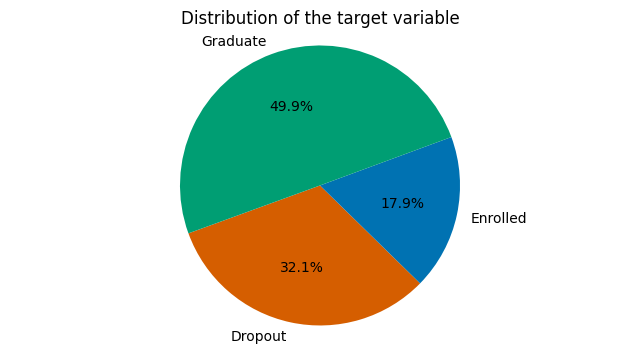

In [11]:
values = target_counts_pd['count']
labels = target_counts_pd['Target'].astype(str)

plt.figure(figsize=(8, 4))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=200,
    colors=['#D55E00', '#0072B2', '#009E73'][:len(values)]
)

plt.title('Distribution of the target variable')
plt.axis('equal')
plt.savefig(FIG_DIR / '15_target_3class.png', dpi=150, bbox_inches='tight')
plt.show()

| Class | Percentage | Meaning |
| --------------- | ---------- | ---------------------------------------- |
| **Graduate** | 49.9% | Completed the programme |
| **Dropout** | 32.1% | Left before completing |
| **Enrolled** | 17.9% | Still studying |

- About half of the students in the dataset graduated (≈ 50%).
- Roughly one third (32%) dropped out — this is the group the risk model needs to identify.
- The remaining 18% are still enrolled; their final outcome is not yet known.

## Binary encoding of the target

In the source data the `Target` column has three values:

- `Dropout` — the student left the programme
- `Enrolled` — the student is still studying
- `Graduate` — the student completed the programme

The research question here is a **binary** one:

> "Will this student drop out or not?"

So the target is encoded as:

- **1** — Dropout
- **0** — Not dropout (both `Enrolled` and `Graduate`)

### Why `Enrolled` is kept and counted as 0

The 794 `Enrolled` students have not left the programme at the time the data was collected, so at that moment they belong to the "not dropout" group. Two alternatives were considered:

| Option | Consequence |
|---|---|
| Drop the `Enrolled` rows | Loses 17.9% of the sample, and produces a model that has never seen a student "in progress" — which is exactly the group an early-warning system has to score |
| **Keep them, labelled 0** ✅ | Uses the whole sample; the label is correct *as of the observation date* |

The limitation this creates is stated openly: some of these students may drop out later, so the label is a **snapshot**, not a final outcome. This is noted again in the conclusions.


In [12]:
# Binary encoding on the FULL dataset — the same population the models use.
data_viz['Target_Encoded'] = (data_viz['Target'] == 'Dropout').astype(int)

print(f'{len(data_viz)} students · dropout = {data_viz["Target_Encoded"].mean():.1%}')


4424 students · dropout = 32.1%


In [13]:
# Illustrate the distribution of the encoded target variable
value_counts_series = data_viz_pd['Target_Encoded'].value_counts()
labels_map = {0: 'Not dropout', 1: 'Dropout'}
display_names = [labels_map[val] for val in value_counts_series.index.to_list()]

fig = px.pie(values=value_counts_series.values,
             names=display_names)

fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(colors=['#009E73', '#D55E00']))

fig.update_layout(showlegend=False, height=400, width=800,
                  title='Target distribution after binary encoding')
save_fig(fig, '06_target_binary_pie')

print(value_counts_series.rename(index=labels_map).to_string())


Target_Encoded
Not dropout    3003
Dropout        1421


### Observation

The pie chart shows the share of students who dropped out (1) versus those who did not (0), over the **complete sample of 4,424 students**:

- **0 — did not drop out: 67.9%** (3,003 students = 2,209 `Graduate` + 794 `Enrolled`)
- **1 — dropped out: 32.1%** (1,421 students)

The dataset is therefore **imbalanced**: the non-dropout group is roughly twice the size of the dropout group.

This matters during training, because a model that always answers "not dropout" already scores **67.9% accuracy** without learning anything (**class imbalance bias**). It is the reason the models later use `is_unbalance` / `scale_pos_weight` / `auto_class_weights`, and are selected on **AUC rather than accuracy**.


## Age at enrollment

In [14]:
fig = px.histogram(
    data_viz_pd,
    x='Age at enrollment',
    facet_col='Target',
    color='Target',
    nbins=30,
    histnorm='percent',
    opacity=0.85,
    color_discrete_map={
        'Graduate': '#0072B2',
        'Dropout': '#D55E00',
        'Enrolled': '#009E73'
    }
)

fig.update_layout(
    title={
        'text': 'Age at enrollment by academic outcome',
        'x': 0.5
    },
    xaxis_title='Age at enrollment',
    yaxis_title='Percentage (%)',
    height=450,
    width=1100,
    showlegend=False
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
save_fig(fig, '07_age_by_outcome')

print(data_viz_pd.groupby('Target')['Age at enrollment']
      .describe()[['count', 'mean', '50%', 'max']].round(1).to_string())


           count  mean   50%   max
Target                            
Dropout   1421.0  26.1  23.0  70.0
Enrolled   794.0  22.4  20.0  54.0
Graduate  2209.0  21.8  19.0  62.0


### Observation

- The distribution is right-skewed: most students are in their late teens to early twenties.
- The three groups separate clearly by age: the median age at enrolment is **19** for `Graduate`, **20** for `Enrolled` and **23** for `Dropout`, and the mean is **21.8 / 22.4 / 26.1** years respectively.
- The dropout rate rises among students in their mid-twenties to early thirties, which is consistent with older students carrying work or family commitments alongside their studies.

The next set of charts is mostly pie charts. To avoid repeating code, two helper functions are defined: one builds a dictionary of target counts per category, and the other turns those dictionaries into pie chart traces.


In [15]:
def get_dictionaries(category_list, dfcolumn_name, target_col, dictionary_list, source_pd):
  '''Return a list of dictionaries with the target counts for each category.

  `source_pd` must be passed explicitly. An earlier version rebuilt the frame
  internally from a hard-coded DataFrame, so when the caller had recoded a
  column (e.g. Debtor 0/1 -> 'No'/'Yes') on a DIFFERENT frame, every filter
  matched nothing and the pie charts came out EMPTY without any error.
  '''
  for each_category in category_list:
    subset = source_pd[source_pd[dfcolumn_name] == each_category]
    if subset.empty:
        raise ValueError(
            f"No row matches {dfcolumn_name} == {each_category!r}. "
            f"Available values: {sorted(source_pd[dfcolumn_name].unique())}")
    dictionary_list.append(dict(subset[target_col].value_counts()))
  return dictionary_list


In [16]:
def make_pie(dictionary_list, trace_list, colors_list, textposition = 'inside'):
  '''This function returns a list of traces for pie charts'''
  for dictionary in dictionary_list:
    trace = go.Pie(values = list(dictionary.values()), labels = list(dictionary.keys()),
           textposition = textposition, textinfo='percent+label',
           marker=dict(colors=colors_list))
    trace_list.append(trace)
  return trace_list

## Gender

In [17]:
# Change gender from numerical to categorical
data_viz['Gender'] = np.where(data_viz['Gender'] == 1, 'Male', 'Female')


In [18]:
percent_count = (data_viz_pd['Gender'].value_counts(normalize=True) * 100).round(1)

df_plot = percent_count.reset_index()
df_plot.columns = ['Gender', 'Percentage (%)']

fig = px.bar(
    df_plot,
    x='Percentage (%)',
    y='Gender',
    orientation='h',
    text='Percentage (%)',
    color='Gender',
    color_discrete_map={
        'Male': '#1A4A96',    # blue
        'Female': '#FF8DA1'  # pink
    }
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Gender distribution in the dataset',
        'x': 0.5
    },
    xaxis=dict(
        title='Percentage (%)',
        range=[0, 100],
        ticksuffix='%'
    ),
    yaxis_title='Gender',
    height=420,
    width=720,
    showlegend=False,
    font=dict(size=14)
)

save_fig(fig, '08_gender_distribution')
print(data_viz_pd['Gender'].value_counts().to_string())


Gender
Female    2868
Male      1556


### Observation

- Female students make up about **64.8%** of the dataset (2,868 students).
- Male students make up **35.2%** (1,556 students).

The horizontal bar chart shows a clear gender imbalance in the sample.


Having looked at the overall gender split, the next step is to break gender down by academic outcome (`Target`) — in particular, which group has the higher dropout rate.

In [19]:
df_plot = ( data_viz_pd .groupby(['Gender', 'Target']) .size() .rename('count') .reset_index() )
df_plot['Percentage (%)'] = ( df_plot .groupby('Gender')['count'] .transform(lambda x: x / x.sum() * 100) )
fig = px.bar(
    df_plot,
    x='Target',
    y='Percentage (%)',
    color='Gender',
    barmode='group',
    text=df_plot['Percentage (%)'].round(1).astype(str) + '%',
    color_discrete_map={
        'Male': '#1A4A96',    # blue
        'Female': '#FF8DA1'  # pink
    }
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Academic outcome by gender',
        'x': 0.5
    },
    yaxis_title='Percentage (%)',
    xaxis_title='Academic outcome',
    yaxis=dict(
        range=[0, 100]
    ),
    height=450,
    width=800,
    uniformtext_minsize=12,
    uniformtext_mode='hide'
)

save_fig(fig, '09_outcome_by_gender')

print((pd.crosstab(data_viz_pd['Gender'], data_viz_pd['Target'],
                   normalize='index') * 100).round(1).to_string())


Target  Dropout  Enrolled  Graduate
Gender                             
Female     25.1      17.0      57.9
Male       45.1      19.7      35.2


### Observation

**Male students** (1,556)
- Graduate: 35.2%
- Enrolled: 19.7%
- Dropout: **45.1%**

**Female students** (2,868)
- Graduate: 57.9%
- Enrolled: 17.0%
- Dropout: **25.1%**

The dropout rate among male students is roughly **1.8 times** that of female students.


### Course distribution

In [ ]:
course_mapping = {
    33:   'Biofuel Production Technologies',
    171:  'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)',
}

data_viz['Course_name'] = data_viz['Course'].map(course_mapping)

# Fail fast: any remaining NaN means the mapping does not match the data
n_null = data_viz['Course_name'].isna().sum()
assert n_null == 0, f'{n_null} rows have an unmapped course code — check course_mapping'
print(f'Mapped {len(course_mapping)} degree programmes, no NaN values left')


Mapped 17 degree programmes, no NaN values left


Total number of students in each course, to see which programmes attract the most students.

In [21]:
print(f'{len(data_viz_pd)} rows · has Course_name column: '
      f'{"Course_name" in data_viz_pd.columns}')
print(data_viz_pd['Course_name'].value_counts().to_string())


4424 rows · has Course_name column: True
Course_name
Nursing                                 766
Management                              380
Social Service                          355
Veterinary Nursing                      337
Journalism and Communication            331
Advertising and Marketing Management    268
Management (evening attendance)         268
Tourism                                 252
Communication Design                    226
Animation and Multimedia Design         215
Social Service (evening attendance)     215
Agronomy                                210
Basic Education                         192
Informatics Engineering                 170
Equiniculture                           141
Oral Hygiene                             86
Biofuel Production Technologies          12


In [22]:
df_course_rate = (
    data_viz_pd
    .groupby(['Course_name', 'Target'])
    .size()
    .rename('count')
    .reset_index()
)

df_course_rate['Dropout_rate (%)'] = (
    df_course_rate
    .groupby('Course_name')['count']
    .transform(lambda x: x / x.sum() * 100)
)

# Keep only the Dropout rows
df_course_rate = df_course_rate[df_course_rate['Target'] == 'Dropout']

# Sort by rate, descending
df_course_rate = df_course_rate.sort_values(
    'Dropout_rate (%)', ascending=False
)

In [23]:
fig = px.bar(
    df_course_rate,
    x='Dropout_rate (%)',
    y='Course_name',
    orientation='h',
    text=df_course_rate['Dropout_rate (%)'].round(1).astype(str) + '%',
    color='Dropout_rate (%)',
    color_continuous_scale='Reds'
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Dropout rate by degree programme',
        'x': 0.5
    },
    xaxis_title='Dropout rate (%)',
    yaxis_title='Degree programme',
    xaxis=dict(range=[0, 100]),
    height=600,
    width=900,
    coloraxis_showscale=False,
    uniformtext_minsize=11,
    uniformtext_mode='hide'
)

save_fig(fig, '10_dropout_rate_by_course')


In [24]:
df_rate = (
    data_viz_pd
    .groupby(['Course_name', 'Target'])
    .size()
    .rename('count')
    .reset_index()
)

df_rate['Percent'] = (
    df_rate
    .groupby('Course_name')['count']
    .transform(lambda x: x / x.sum() * 100)
)

fig = px.bar(
    df_rate,
    x='Percent',
    y='Course_name',
    color='Target',
    orientation='h',
    barmode='stack',
    color_discrete_map={'Graduate': '#0072B2',
                        'Dropout': '#D55E00',
                        'Enrolled': '#009E73'}
)

fig.update_layout(
    title={
        'text': 'Academic outcome by degree programme',
        'x': 0.5
    },
    xaxis_title='Percentage (%)',
    yaxis_title='Degree programme',
    xaxis=dict(range=[0, 100]),
    height=650,
    width=1000
)

save_fig(fig, '11_outcome_by_course')

print((pd.crosstab(data_viz_pd['Course_name'], data_viz_pd['Target'],
                   normalize='index') * 100).round(1)
      .sort_values('Dropout', ascending=False).to_string())


Target                                Dropout  Enrolled  Graduate
Course_name                                                      
Biofuel Production Technologies          66.7      25.0       8.3
Equiniculture                            55.3      14.9      29.8
Informatics Engineering                  54.1      37.6       8.2
Management (evening attendance)          50.7      20.1      29.1
Basic Education                          44.3      26.0      29.7
Agronomy                                 41.0      17.6      41.4
Oral Hygiene                             38.4      19.8      41.9
Animation and Multimedia Design          38.1      17.2      44.7
Tourism                                  38.1      16.3      45.6
Advertising and Marketing Management     35.4      17.9      46.6
Management                               35.3      28.4      36.3
Social Service (evening attendance)      33.0       9.8      57.2
Journalism and Communication             30.5      10.3      59.2
Veterinary

### Observation

**1. Programmes with the highest dropout rate**

`Biofuel Production Technologies` (66.7%), `Equiniculture` (55.3%), `Informatics Engineering` (54.1%) and `Management — evening attendance` (50.7%) lose more than half of their intake. Note however that `Biofuel Production Technologies` has only **12 students** in the whole dataset, so its 66.7% rests on 8 people and must not be read as a reliable programme-level rate.

**2. Programmes with the highest graduation rate**

`Nursing` (71.5% of 766 students), `Social Service` (69.9% of 355) and `Journalism and Communication` (59.2% of 331) retain their students best. These are also among the largest programmes, so these figures are the most stable in the table.

**3. Programmes with many students still enrolled**

`Informatics Engineering` (37.6%), `Management` (28.4%) and `Basic Education` (26.0%) have a high share of `Enrolled` students, which can indicate a newer programme or a longer expected duration — their final outcome is not yet known.

> Programme size varies from 12 to 766 students, so the percentages for the small programmes carry a wide margin of error. The chart is read as an indication of *where* to look, not as a ranking.


### Marital status

In [25]:
# Map the numeric codes to text labels.
marital_labels = {1: 'Single', 2: 'Married', 3: 'Widower',
                  4: 'Divorced', 5: 'Facto union', 6: 'Legally Separated'}
data_viz['Marital status'] = (data_viz['Marital status']
                              .map(marital_labels)
                              .fillna(data_viz['Marital status'].astype(str)))
print(data_viz['Marital status'].value_counts().to_string())


Marital status
Single               3919
Married               379
Divorced               91
Facto union            25
Legally Separated       6
Widower                 4


In [26]:
# Bar chart for Marital status
count = data_viz_pd['Marital status'].value_counts()
fig = px.bar(count,  orientation= 'h', text_auto=True)

fig.update_traces(marker=dict(color=['red', 'orange']))
fig.update_layout(height=500, width=800,
                  title='Marital status of the students',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = 'Count',
                  yaxis_title = 'Marital status')
save_fig(fig, '12_marital_status')


- The great majority of students are **single** (3,919 students, roughly 88–90% of the sample). This is expected, since most students are of typical university age.

- A small share are **married** (379 students, about 8–9%), which suggests a group of older or part-time students.

- The remaining categories are very small:

| Status | Count | Note |
| ----------------- | -------- | ------------------------------------------------------ |
| Divorced | 91 | Likely older students or those returning to study |
| Facto union | 25 | Living together without a registered marriage |
| Legally separated | 6 | Negligible |
| Widower | 4 | Very rare |

In [27]:
fig = px.histogram(data_viz_pd, x='Marital status', color = 'Target',
                   width = 1200, height = 500,
                   text_auto='.1f', color_discrete_sequence=px.colors.qualitative.Dark2,
                   barnorm = 'percent', barmode = 'group')

fig.update_layout(title='Marital status', yaxis_title = '% of students')

save_fig(fig, '13_marital_status_by_outcome')


Marital status is clearly related to the academic outcome. Single students have the highest graduation rate, while students in more complex family situations (married, separated, divorced) drop out considerably more often — plausibly because of competing demands on their time, finances or emotional capacity.

In [28]:
def sub_plots(chart_to_plot, row, col):
  '''This function generates the list of subplots'''
  cols = chart_to_plot * col
  rows = [cols] * row
  return rows

### Financial situation of the students

Next, the financial situation is analysed to see how scholarship status, debt status and tuition payment status relate to the dropout rate.

In [29]:
# Converting columns back to categorical
for c in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']:
    data_viz[c] = np.where(data_viz[c] == 1, 'Yes', 'No')


In [30]:
# Getting dictionaries for students in debt / not in debt
debt = sorted(data_viz_pd['Debtor'].unique())
debt_dictionaries = get_dictionaries(debt, 'Debtor', 'Target', [], data_viz_pd)
print(dict(zip(debt, debt_dictionaries)))


{'No': {'Graduate': 2108, 'Dropout': 1109, 'Enrolled': 704}, 'Yes': {'Dropout': 312, 'Graduate': 101, 'Enrolled': 90}}


In [31]:
# Getting dictionaries for students with tuition fees paid / not paid
tuition = sorted(data_viz_pd['Tuition fees up to date'].unique())
tuition_dictionaries = get_dictionaries(tuition, 'Tuition fees up to date', 'Target', [], data_viz_pd)
print(dict(zip(tuition, tuition_dictionaries)))


{'No': {'Dropout': 457, 'Enrolled': 42, 'Graduate': 29}, 'Yes': {'Graduate': 2180, 'Dropout': 964, 'Enrolled': 752}}


In [32]:
# Getting dictionaries for students with / without a scholarship
scholarship = sorted(data_viz_pd['Scholarship holder'].unique())
scholarship_dictionaries = get_dictionaries(scholarship, 'Scholarship holder', 'Target', [], data_viz_pd)
print(dict(zip(scholarship, scholarship_dictionaries)))


{'No': {'Graduate': 1374, 'Dropout': 1287, 'Enrolled': 664}, 'Yes': {'Graduate': 835, 'Dropout': 134, 'Enrolled': 130}}


In [33]:
# Creating subplots for the pie charts.
# `sorted()` above puts 'No' before 'Yes', so the subplot titles follow that order.
fig = make_subplots(rows=3, cols=2,
                    subplot_titles = ['No debt', 'In debt',
                                      'Tuition unpaid', 'Tuition paid',
                                      'No scholarship', 'Scholarship holder'],
                    specs= sub_plots([{'type':'pie'}], 3,2), vertical_spacing = 0.07)

# Initialize an empty list for traces
traces = []

# Generate traces
make_pie(debt_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])
make_pie(tuition_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])
make_pie(scholarship_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])

for i, tr in enumerate(traces):
    fig.add_trace(tr, row=i // 2 + 1, col=i % 2 + 1)

fig.update_layout(title="Financial situation of the students", height=1000, width=1000,
                  showlegend=False, title_pad=dict(t=100))
save_fig(fig, '14_financial_situation')

# Print the underlying numbers so the commentary below can be checked against them
for c in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']:
    print(f'\n--- {c} — outcome (%) ---')
    print((pd.crosstab(data_viz_pd[c], data_viz_pd['Target'], normalize='index') * 100)
          .round(1).to_string())



--- Debtor — outcome (%) ---
Target  Dropout  Enrolled  Graduate
Debtor                             
No         28.3      18.0      53.8
Yes        62.0      17.9      20.1

--- Tuition fees up to date — outcome (%) ---
Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
No                          86.6       8.0       5.5
Yes                         24.7      19.3      56.0

--- Scholarship holder — outcome (%) ---
Target              Dropout  Enrolled  Graduate
Scholarship holder                             
No                     38.7      20.0      41.3
Yes                    12.2      11.8      76.0


### Observation

Computed on the full sample of 4,424 students:

| Group | n | Dropout | Enrolled | Graduate |
|---|---|---|---|---|
| Not in debt | 3,921 | 28.3% | 18.0% | 53.8% |
| **In debt** | 503 | **62.0%** | 17.9% | 20.1% |
| **Tuition unpaid** | 528 | **86.6%** | 8.0% | 5.5% |
| Tuition paid | 3,896 | 24.7% | 19.3% | 56.0% |
| No scholarship | 3,325 | 38.7% | 20.0% | 41.3% |
| **Scholarship holder** | 1,099 | **12.2%** | 11.8% | 76.0% |

Students who are in debt or who have not paid their tuition drop out far more often — **62.0%** and **86.6%** respectively, against a base rate of 32.1%. Scholarship holders drop out much less (**12.2%**) than students without a scholarship (**38.7%**).

> **Read as association, not as cause.** Unpaid tuition can just as easily be a *consequence* of a student having already decided to leave as a cause of leaving. What the figure establishes is that the payment status is a very strong **early signal**, which is what an alert system needs.

The EDA has now covered how the data is distributed by gender and age, and how features such as the enrolled course and the financial situation relate to dropout. The next stage builds and trains classification models to see whether they agree with these findings.

### Preparing the data — feature selection

The simplest way to see how the independent features relate to each other is a correlation analysis. It highlights which variables carry overlapping information and could be dropped or combined to avoid multicollinearity. A heatmap makes this easy to read.


In [34]:
# Pearson correlation — NUMERIC and BINARY columns only.
# Pearson measures a LINEAR relationship between quantities. Applying it to a
# nominal code (Course 33 ... 9991, Father's occupation 0 ... 195) is meaningless:
# the number is a label, not a magnitude. Those columns are handled separately
# in the next cell with Cramer's V.
data_pd = data

NOMINAL = ['Marital status', 'Application mode', 'Course', 'Nationality',
           'Previous qualification', "Mother's qualification",
           "Father's qualification", "Mother's occupation", "Father's occupation"]

numeric_cols = [c for c in data_pd.columns if c not in NOMINAL + ['Target']]
correlation_matrix = data_pd[numeric_cols].corr().round(2)

fig = px.imshow(correlation_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title='Pearson correlation between the numeric / binary features',
                  height=800, width=1400)
save_fig(fig, '01_correlation_numeric')

print(f'{len(numeric_cols)} numeric or binary columns shown · '
      f'{len(NOMINAL)} nominal columns excluded (see the next cell)')


27 numeric or binary columns shown · 9 nominal columns excluded (see the next cell)


### Observation — numeric features

Only one block stands out: the twelve `Curricular units` variables are strongly correlated with each other, as expected — they all measure study progress in the first year. That block is examined on its own two cells below.

Nothing else among the numeric variables is redundant enough to justify removing it.

### The nominal variables need a different statistic

Pearson correlation cannot be used on the nominal columns. `Course` is coded 33, 171, 8014 … 9991 and `Father's occupation` 0 … 195; those numbers are **labels, not magnitudes**, so "correlation" between them measures nothing but the accident of how the codes were assigned.

The correct measure of association between two categorical variables is **Cramér's V** (0 = independent, 1 = one variable determines the other). The next cell computes it — and the answer changes one of the decisions that had been taken on the Pearson figures.


In [35]:
# Cramer's V — association between two CATEGORICAL variables (0 = independent, 1 = determines).
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    t = pd.crosstab(a, b)
    chi2 = chi2_contingency(t)[0]
    n = t.values.sum()
    r, k = t.shape
    phi2 = chi2 / n
    phi2c = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))          # bias correction
    rc = r - ((r - 1) ** 2) / (n - 1)
    kc = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2c / max(1e-12, min(kc - 1, rc - 1)))

pairs = [('Nationality', 'International'),
         ("Mother's occupation", "Father's occupation"),
         ("Mother's qualification", "Father's qualification"),
         ('Course', 'Application mode')]

print(f"{'pair':58s} {'Cramer V':>9s} {'Pearson':>9s}")
print('-' * 79)
for a, b in pairs:
    v = cramers_v(data_pd[a], data_pd[b])
    p = data_pd[a].corr(data_pd[b])
    flag = '  <- duplicate' if v > 0.95 else ''
    print(f'{a + " x " + b:58s} {v:9.3f} {p:9.3f}{flag}')

print('\nNationality vs International — the actual contingency table:')
print(pd.crosstab(data_pd['Nationality'] == 1, data_pd['International'],
                  rownames=['Nationality == 1 (Portuguese)'], colnames=['International']))


pair                                                        Cramer V   Pearson
-------------------------------------------------------------------------------
Nationality x International                                    0.998     0.791  <- duplicate
Mother's occupation x Father's occupation                      0.571     0.910
Mother's qualification x Father's qualification                0.431     0.535
Course x Application mode                                      0.168     0.065

Nationality vs International — the actual contingency table:
International                     0    1
Nationality == 1 (Portuguese)           
False                             0  110
True                           4314    0


### What Cramér's V shows

| Pair | Cramér's V | Pearson | Reading |
|---|---|---|---|
| `Nationality` × `International` | **0.998** | 0.791 | One **determines** the other |
| `Mother's occupation` × `Father's occupation` | **0.571** | 0.910 | Related, **not** duplicated |
| `Mother's qualification` × `Father's qualification` | **0.431** | 0.535 | Related, **not** duplicated |
| `Course` × `Application mode` | 0.168 | — | Essentially independent |

Two findings matter here.

**1. `Nationality` and `International` really are the same variable.** The contingency table is exact: `International = 1` for every student whose `Nationality` is not 1 (Portuguese), and 0 for every student whose `Nationality` is 1. There is no row that breaks the rule, so one of the two carries no information the other does not. `Nationality` is dropped.

**2. The parents' variables are *not* duplicates — and Pearson said they were.** For the two occupation columns Pearson reports 0.910, which looks like near-perfect redundancy. Cramér's V reports 0.571. The gap is an artefact of the coding: the occupation codes are ordered by socio-economic group, so both parents of the same household tend to fall in the same numeric range, and Pearson reads that ordering as a linear relationship.


In [ ]:
# Drop only the four columns justified above.
# `Mother's occupation` and `Father's qualification` are KEPT: Pearson made them
# look redundant (0.910 / 0.535) but Cramer's V says otherwise (0.571 / 0.431),
columns_to_drop = ['Nationality',                       # Cramer V = 0.998 with International
                   'Unemployment rate',                 # |corr with dropout| = 0.013
                   'Inflation rate',                    # |corr with dropout| = 0.028
                   'GDP']                               # |corr with dropout| = 0.046

data = data.drop(columns=columns_to_drop)

kept = [c for c in data.columns if c.startswith('Curricular')]
print(f'{len(data.columns)} columns left ({len(data.columns) - 1} features + Target)')
print(f'kept {len(kept)} Curricular units variables:')
for c in kept:
    print(f'  - {c}')
print("\nkept the parents' variables:")
for c in data.columns:
    if 'Mother' in c or 'Father' in c:
        print(f'  - {c}')


33 columns left (32 features + Target)
kept 12 Curricular units variables:
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (grade)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 2nd sem (without evaluations)

kept the parents' variables:
  - Mother's qualification
  - Father's qualification
  - Mother's occupation
  - Father's occupation


In [37]:
# Correlation heat map after the drop — numeric / binary columns only
data_pd = data
numeric_cols = [c for c in data_pd.columns if c not in NOMINAL + ['Target']]
correlation_matrix = data_pd[numeric_cols].corr().round(2)

fig = px.imshow(correlation_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title='Correlation between the numeric features (after the drop)',
                  height=800, width=1400)
save_fig(fig, '02_correlation_after_drop')


## Data processing

Before scaling the data, the target column has to be converted from a category to a number.

In [38]:
# Convert Target to binary (1 for Dropout, 0 for others).
# `Enrolled_flag` is carried alongside — NOT as a feature — so that the
# sensitivity analysis at the end of the notebook can remove those students
# and check whether the conclusions depend on how they were labelled.
data['Enrolled_flag'] = (data['Target'] == 'Enrolled').astype(int)
data['Target'] = (data['Target'] == 'Dropout').astype(int)

print(data.groupby(['Target', 'Enrolled_flag']).size().rename('count').to_string())


Target  Enrolled_flag
0       0                2209
        1                 794
1       0                1421


In [ ]:
# Features and label.
feature_columns = [c for c in data.columns if c not in ('Target', 'Enrolled_flag')]

X   = data[feature_columns]
y   = data['Target'].to_numpy()
enr = data['Enrolled_flag'].to_numpy()

print(f'{len(feature_columns)} features · {len(X)} students · dropout = {y.mean():.1%}')
X.head()


32 features · 4424 students · dropout = 32.1%


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations)
0,1,17,5,171,1,1,122.0,19,12,5,...,0,0,0.000000,0,0,0,0,0,0.000000,0
1,1,15,1,9254,1,1,160.0,1,3,3,...,6,6,14.000000,0,0,6,6,6,13.666667,0
2,1,1,5,9070,1,1,122.0,37,37,9,...,0,0,0.000000,0,0,6,0,0,0.000000,0
3,1,17,2,9773,1,1,122.0,38,37,5,...,8,6,13.428571,0,0,6,10,5,12.400000,0
4,2,39,1,8014,0,1,100.0,37,38,9,...,9,5,12.333333,0,0,6,6,6,13.000000,0


## Model building

The target is categorical (dropout or not), so this is a classification problem. Two families of models are compared:

**Baseline models** (reference points) — logistic regression · decision tree · linear support vector machine
**Ensemble models** (the focus of this study) — LightGBM · XGBoost · CatBoost

### The evaluation protocol

The data is used in exactly two roles, and the boundary between them is never crossed.

| Role | Share | What touches it |
|---|---|---|
| **Training pool** | 80% (3,539 students) | everything — encoding, scaling, hyper-parameter search, cross-validation |
| **Holdout test set** | 20% (885 students) | **nothing until the very last step**, when each final model is scored on it once |

Both splits are **stratified**, so all parts carry the same 32,1% dropout rate.

Inside the training pool, every model is measured by **10-fold stratified cross-validation**: the pool is cut into ten equal parts, and each part is scored by a model that was fitted on the other nine. Every student is therefore predicted exactly once by a model that never saw them, and the result is ten independent estimates rather than one.

> **Why there is no fixed validation set any more.** An earlier version of this notebook carved a single 708-student validation slice out of the training pool and tuned on it. That wastes data — those 708 students never contributed to training — and, more importantly, a single slice of 708 is a noisy yardstick: the split-variation experiment further below shows that one draw of this size moves the AUC by up to 0,038. Ten folds average that noise out and let the *spread* be reported alongside the mean.


In [40]:
# Train / test split — STRATIFIED, and this is the ONLY split of the raw data.
# X_test is the sealed holdout: nothing below touches it until the final evaluation.
X_train, X_test, y_train, y_test, enr_train, enr_test = train_test_split(
    X, y, enr, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training pool (used for encoding, scaling, tuning and CV): "
      f"{len(X_train)}  (dropout {y_train.mean():.1%})")
print(f"Holdout test set (sealed until the final evaluation):      "
      f"{len(X_test)}  (dropout {y_test.mean():.1%})")


Training pool (used for encoding, scaling, tuning and CV): 3539  (dropout 32.1%)
Holdout test set (sealed until the final evaluation):      885  (dropout 32.1%)


### Preventing leakage inside the cross-validation

Logistic regression and the linear SVM need standardised inputs, and that is where cross-validation is easy to get wrong.

Standardising **before** the folds are cut — `StandardScaler().fit(X_train)` followed by `cross_val_score` — lets the mean and standard deviation of every validation fold influence the numbers the model trains on. The fold is then no longer unseen, and the reported score is optimistic.

The fix is to make the scaler part of the **model**:

```python
Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(...))])
```

`cross-validation` then clones that whole pipeline for each fold and calls `fit` on the nine training folds only, so the scaler learns its mean and standard deviation from those nine folds and merely *applies* them to the held-out tenth. Ten folds means ten independently fitted scalers. The same object is refitted on the whole training pool for the final holdout evaluation, and the holdout is scaled with statistics it never contributed to.

**The tree-based models get the raw, unscaled DataFrame.** They are invariant to monotone transforms, so scaling buys them nothing — and keeping the original values is what lets SHAP report *"Age at enrollment = 34"* instead of *"Age at enrollment = 4.51"*.


In [41]:
# ---------------------------------------------------------------------------
# Cross-validation machinery
# ---------------------------------------------------------------------------
import itertools
from sklearn.base import clone

CV_FOLDS = 10
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def risk_score(model, X_eval):
    """Continuous score for AUC. LinearSVC has no predict_proba — use its margin."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    return model.decision_function(X_eval)

def cv_auc(make_model, X_src, fit_kwargs=None):
    """One AUC per fold, always fitting from scratch inside the fold."""
    fit_kwargs = fit_kwargs or {}
    out = []
    for tr, va in skf.split(X_src, y_train):
        m = make_model()
        m.fit(X_src.iloc[tr], y_train[tr], **fit_kwargs)
        out.append(roc_auc_score(y_train[va], risk_score(m, X_src.iloc[va])))
    return np.array(out)

def scaled(estimator):
    """Wrap a scale-sensitive model so the scaler is refitted inside every fold."""
    return Pipeline([('scaler', StandardScaler()), ('clf', estimator)])

cv_scores = {}          # model name -> array of CV_FOLDS AUC values

print(f'{CV_FOLDS}-fold stratified CV over {len(X_train)} students '
      f'({len(X_train) // CV_FOLDS} per fold, dropout {y_train.mean():.1%})')


10-fold stratified CV over 3539 students (353 per fold, dropout 32.1%)


### The majority-class baseline

Before any model, the number to beat: a constant predictor that always answers "not dropout".


In [42]:
counts = pd.Series(y).value_counts()
print("Target value counts:")
print(counts.rename({0: 'not dropout', 1: 'dropout'}).to_string())

baseline_acc = round(counts.max() / counts.sum() * 100, 3)
print(f'\nTotal samples: {counts.sum()}')
print(f'The baseline accuracy to beat is {baseline_acc}%')
print('=> Accuracy alone is not a meaningful criterion here; AUC is used throughout.')


Target value counts:
not dropout    3003
dropout        1421

Total samples: 4424
The baseline accuracy to beat is 67.88%
=> Accuracy alone is not a meaningful criterion here; AUC is used throughout.


### Class imbalance — handled identically for all six models

Dropout is the minority class (32,1%). Every model is told so, in the way its own library expects, so the comparison measures the algorithms and not the weighting:

| Model | Setting |
|---|---|
| Logistic regression · Decision tree · LinearSVC | `class_weight='balanced'` |
| LightGBM | `is_unbalance=True` |
| XGBoost | `scale_pos_weight` = negatives / positives |
| CatBoost | `auto_class_weights='Balanced'` |

### Encoding the nominal variables

`Course` is coded 33 … 9991 and `Father's occupation` 0 … 195. Those numbers are **labels, not magnitudes**, so a split of the form "Course < 9200" is meaningless. Declaring the eight nominal columns as pandas `category` makes the boosting models split on group membership instead. Because the data never leaves pandas this is a one-line dtype change.


In [43]:
# ---------------------------------------------------------------------------
# Encoding for the three boosters. The baselines keep the plain numeric frame —
# see the "Limitation" section further below for why they are not one-hot encoded.
# ---------------------------------------------------------------------------
CATEGORICAL_COLS = [c for c in NOMINAL if c in feature_columns]
_levels = {c: sorted(X[c].unique()) for c in CATEGORICAL_COLS}

def to_categorical_df(frame):
    """Nominal columns typed as `category` (LightGBM / XGBoost)"""
    d = frame.copy()
    for c in CATEGORICAL_COLS:
        d[c] = pd.Categorical(d[c].astype(int), categories=_levels[c])
    return d

def to_int_df(frame):
    """Nominal columns as plain integers (CatBoost)"""
    d = frame.copy()
    for c in CATEGORICAL_COLS:
        d[c] = d[c].astype(int)
    return d

X_train_df, X_test_df = to_categorical_df(X_train), to_categorical_df(X_test)
X_train_cb, X_test_cb = to_int_df(X_train),         to_int_df(X_test)

# The features in their ORIGINAL units — used for displaying the SHAP plots
X_test_disp = X_test.reset_index(drop=True).astype(float)

spw = (y_train == 0).sum() / (y_train == 1).sum()

print(f'{len(CATEGORICAL_COLS)} nominal variables declared as `category`:')
for c in CATEGORICAL_COLS:
    print(f'  - {c:32s} ({len(_levels[c])} levels)')
print(f'\nscale_pos_weight for XGBoost = {spw:.3f}')
print(f"'Enrolled' students (label 0, kept for the sensitivity analysis): "
      f"{int(enr_train.sum())} in the training pool · {int(enr_test.sum())} in the holdout")


8 nominal variables declared as `category`:
  - Marital status                   (6 levels)
  - Application mode                 (18 levels)
  - Course                           (17 levels)
  - Previous qualification           (17 levels)
  - Mother's qualification           (29 levels)
  - Father's qualification           (34 levels)
  - Mother's occupation              (32 levels)
  - Father's occupation              (46 levels)

scale_pos_weight for XGBoost = 2.113
'Enrolled' students (label 0, kept for the sensitivity analysis): 632 in the training pool · 162 in the holdout


### Saving the trained models — so a re-run costs seconds, not half an hour

The expensive part of this notebook is **not** fitting the final models (six fits, a few seconds). It is the hyper-parameter search: 48 configurations × 10 folds × 3 boosters is about **1,440 model fits**, roughly half an hour.

Everything expensive is therefore written to `09_MoHinh/` and reloaded on the next run — the fitted models themselves, the selected hyper-parameters, and the per-fold AUC arrays behind every number in the tables below.

**A cache that silently serves stale numbers would be worse than no cache**, so each entry stores a *fingerprint* of everything it depends on:

| Part of the fingerprint | Why it must invalidate the cache |
|---|---|
| Hash of `X_train` and `y_train` | a different split, or a change in the dropped columns, changes every result |
| `RANDOM_STATE`, `CV_FOLDS` | a different fold structure gives different scores |
| The hyper-parameter grid | a wider search can find a different winner |
| `feature_columns`, `CATEGORICAL_COLS` | different inputs or a different encoding |
| `CACHE_VERSION` | the manual escape hatch — see below |

If any of those change, the entry is recomputed automatically and the notebook says so. Every cell prints whether its numbers were **loaded** or **recomputed**, so it is always visible which is which.

> ⚠️ **The fingerprint cannot see the model constructors.** Editing e.g. `max_iter` or `is_unbalance` inside a cell will *not* invalidate anything by itself. After changing any model setting, either bump `CACHE_VERSION` by one or set `USE_CACHE = False` for one run.


In [44]:
# ---------------------------------------------------------------------------
# Persistent cache for everything expensive.
#   USE_CACHE = False  -> ignore what is on disk and recompute everything
#   CACHE_VERSION += 1 -> invalidate by hand after editing a model's settings
# ---------------------------------------------------------------------------
import hashlib
import joblib

MODEL_DIR = Path('09_MoHinh')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

USE_CACHE = True
CACHE_VERSION = 1

def _frame_hash(frame):
    return int(pd.util.hash_pandas_object(frame, index=True).sum())

_BASE_FINGERPRINT = (
    CACHE_VERSION,
    _frame_hash(X_train), _frame_hash(pd.Series(y_train)),
    _frame_hash(X_test),  _frame_hash(pd.Series(y_test)),
    RANDOM_STATE, CV_FOLDS,
    tuple(feature_columns), tuple(CATEGORICAL_COLS),
)

def fingerprint(extra=None):
    h = hashlib.sha1(repr((_BASE_FINGERPRINT, extra)).encode()).hexdigest()
    return h[:16]

def cached(name, build, extra=None):
    """Return build(), reusing the stored result when the fingerprint still matches."""
    path = MODEL_DIR / f'{name}.joblib'
    fp = fingerprint(extra)

    if USE_CACHE and path.exists():
        blob = joblib.load(path)
        if blob.get('fingerprint') == fp:
            print(f'  [cache] loaded  {name}')
            return blob['value']
        print(f'  [cache] STALE    {name} — inputs changed, recomputing')
    elif USE_CACHE:
        print(f'  [cache] missing  {name} — computing')
    else:
        print(f'  [cache] disabled {name} — computing')

    value = build()
    joblib.dump({'fingerprint': fp, 'value': value}, path)
    return value

print(f'Cache directory : {MODEL_DIR.resolve()}')
print(f'USE_CACHE       : {USE_CACHE}   ·   CACHE_VERSION: {CACHE_VERSION}')
print(f'Fingerprint     : {fingerprint()}')
existing = sorted(MODEL_DIR.glob('*.joblib'))
print(f'Stored entries  : {len(existing)}'
      + (''.join(f"\n  - {f.name}" for f in existing) if existing else ' (first run)'))


Cache directory : /Users/macvn/Projects/Master_Class/Thesis/09_MoHinh
USE_CACHE       : True   ·   CACHE_VERSION: 1
Fingerprint     : 5a7435bdc529e6f2
Stored entries  : 10
  - augmentation_models.joblib
  - cv_decision_tree.joblib
  - cv_logistic_regression.joblib
  - cv_svc.joblib
  - dtree_depth_sweep.joblib
  - final_models.joblib
  - split_variation.joblib
  - tuning_catboost.joblib
  - tuning_lightgbm.joblib
  - tuning_xgboost.joblib


### Baseline 1 — logistic regression

In [45]:
make_lr = lambda: scaled(LogisticRegression(max_iter=1000, class_weight='balanced',
                                            random_state=RANDOM_STATE))

cv_scores['Logistic Regression'] = cached('cv_logistic_regression',
                                          lambda: cv_auc(make_lr, X_train))
print(f"Logistic Regression — {CV_FOLDS}-fold CV AUC = "
      f"{cv_scores['Logistic Regression'].mean():.4f} "
      f"+/- {cv_scores['Logistic Regression'].std():.4f}")


  [cache] loaded  cv_logistic_regression
Logistic Regression — 10-fold CV AUC = 0.9140 +/- 0.0172


### Baseline 2 — decision tree

The only hyper-parameter tuned here is the depth, and it is now selected by **cross-validated AUC** rather than by accuracy on a single validation slice. The curve below is the cross-validated learning curve: each point is the mean over the ten folds.


In [46]:
# Depth selected by cross-validated AUC. Trees need no scaling.
depth_values = list(range(1, 21))

def _sweep_depths():
    means, stds = [], []
    for d in tqdm(depth_values, desc='decision tree depth'):
        a = cv_auc(lambda d=d: DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                                      random_state=RANDOM_STATE), X_train)
        means.append(a.mean())
        stds.append(a.std())
    return np.array(means), np.array(stds)

depth_cv_mean, depth_cv_std = cached('dtree_depth_sweep', _sweep_depths,
                                     extra=tuple(depth_values))
best_depth = depth_values[int(depth_cv_mean.argmax())]
print(f'\nBest depth by {CV_FOLDS}-fold CV AUC: {best_depth} '
      f'(AUC {depth_cv_mean.max():.4f})')


  [cache] loaded  dtree_depth_sweep

Best depth by 10-fold CV AUC: 4 (AUC 0.8717)


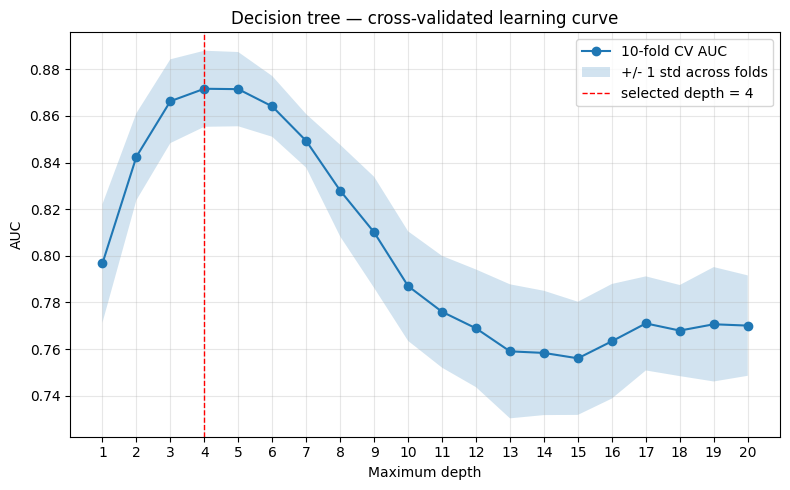

  [cache] loaded  cv_decision_tree
Decision Tree — 10-fold CV AUC = 0.8717 +/- 0.0163


In [47]:
# Cross-validated learning curve
plt.figure(figsize=(8, 5))
plt.plot(depth_values, depth_cv_mean, 'o-', label=f'{CV_FOLDS}-fold CV AUC')
plt.fill_between(depth_values, depth_cv_mean - depth_cv_std, depth_cv_mean + depth_cv_std,
                 alpha=0.2, label='+/- 1 std across folds')
plt.axvline(best_depth, color='red', linestyle='--', linewidth=1,
            label=f'selected depth = {best_depth}')
plt.xlabel('Maximum depth')
plt.ylabel('AUC')
plt.title('Decision tree — cross-validated learning curve')
plt.xticks(depth_values)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '16_dtree_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

make_tree = lambda: DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced',
                                           random_state=RANDOM_STATE)
cv_scores['Decision Tree'] = cached('cv_decision_tree',
                                    lambda: cv_auc(make_tree, X_train),
                                    extra=best_depth)
print(f"Decision Tree — {CV_FOLDS}-fold CV AUC = "
      f"{cv_scores['Decision Tree'].mean():.4f} +/- {cv_scores['Decision Tree'].std():.4f}")


### Baseline 3 — linear support vector machine

`LinearSVC` is the linear-kernel SVM. Unlike the other models it produces no probability, only a signed distance to the separating hyperplane; that margin is a perfectly valid ranking score and is what its AUC is computed from.


In [48]:
make_svc = lambda: scaled(LinearSVC(max_iter=5000, class_weight='balanced',
                                    random_state=RANDOM_STATE))

cv_scores['SVC'] = cached('cv_svc', lambda: cv_auc(make_svc, X_train))
print(f"SVC — {CV_FOLDS}-fold CV AUC = "
      f"{cv_scores['SVC'].mean():.4f} +/- {cv_scores['SVC'].std():.4f}")


  [cache] loaded  cv_svc
SVC — 10-fold CV AUC = 0.9145 +/- 0.0174


### Hyper-parameter search for the three ensembles

All three boosters are searched over the **same 48-configuration grid**, with the **same selection criterion** — the mean AUC over the ten folds — so the comparison between them is fair.

> **Cost.** 48 configurations × 10 folds × 3 models is about 1,440 model fits and takes roughly half an hour. Setting `CV_FOLDS = 5` above halves it.

> ⚠️ **Selection bias, stated openly.** The configuration is chosen by the same cross-validation that reports its score, so the CV figure of the *winning* configuration is **slightly optimistic** — it is the maximum of 48 noisy estimates. That is the price of not spending a nested cross-validation on a 4,424-row dataset. It is also exactly why the holdout exists: the final numbers reported at the end come from 885 students that took no part in any of this, and those are unbiased.


In [49]:
def tune_by_cv(make_model, grid, name, X_src, fit_kwargs=None):
    """Pick hyper-parameters by mean AUC over the CV folds of the training pool.

    The search is the expensive part of the notebook, so its result is cached:
    the winning parameters AND the per-fold AUC array behind them.
    """
    def _search():
        combos = [dict(zip(grid.keys(), v)) for v in itertools.product(*grid.values())]
        best = {'auc': -1.0, 'params': None, 'folds': None}
        for p in tqdm(combos, desc=name):
            a = cv_auc(lambda p=p: make_model(p), X_src, fit_kwargs)
            if a.mean() > best['auc']:
                best = {'auc': float(a.mean()), 'params': p, 'folds': a}
        return best

    best = cached(f'tuning_{name.lower()}', _search, extra=grid)
    print(f"\n{name} — best parameters: {best['params']}")
    print(f"{name} — {CV_FOLDS}-fold CV AUC: {best['auc']:.4f} +/- {best['folds'].std():.4f}")
    cv_scores[name] = best['folds']
    return best

# The same 48-configuration search space for all three models
COMMON_GRID = {'learning_rate': [0.01, 0.05, 0.1],
               'n_estimators':  [50, 100, 150, 200],
               'max_depth':     [3, 5, 7, 10]}

best_lgb = tune_by_cv(
    lambda p: lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                                 random_state=RANDOM_STATE, verbose=-1, **p),
    COMMON_GRID, 'LightGBM', X_train_df)


  [cache] loaded  tuning_lightgbm

LightGBM — best parameters: {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 3}
LightGBM — 10-fold CV AUC: 0.9186 +/- 0.0122


**XGBoost.** `scale_pos_weight` plays the role of `is_unbalance`, and `enable_categorical=True` with `tree_method='hist'` lets it split the nominal variables on group membership the same way LightGBM does.

In [50]:
from xgboost import XGBClassifier

best_xgb = tune_by_cv(
    lambda p: XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                            scale_pos_weight=spw, enable_categorical=True,
                            tree_method='hist', random_state=RANDOM_STATE,
                            verbosity=0, **p),
    COMMON_GRID, 'XGBoost', X_train_df)


  [cache] loaded  tuning_xgboost

XGBoost — best parameters: {'learning_rate': 0.05, 'n_estimators': 200, 'max_depth': 3}
XGBoost — 10-fold CV AUC: 0.9183 +/- 0.0121


**CatBoost.** Uses ordered boosting, and applies ordered target statistics to the columns named in `cat_features`.

> **Implementation note.** `cat_features` is passed to **`fit()`**, not to the constructor. CatBoost mutates that argument internally, which breaks `sklearn.base.clone()` — and cloning is what every fold of the cross-validation relies on.


In [51]:
from catboost import CatBoostClassifier, Pool

CAT_GRID = {'learning_rate': COMMON_GRID['learning_rate'],
            'iterations':    COMMON_GRID['n_estimators'],
            'depth':         [3, 5, 7, 10]}

best_cat = tune_by_cv(
    lambda p: CatBoostClassifier(loss_function='Logloss', auto_class_weights='Balanced',
                                 random_seed=RANDOM_STATE, verbose=0,
                                 allow_writing_files=False, **p),
    CAT_GRID, 'CatBoost', X_train_cb,
    fit_kwargs={'cat_features': CATEGORICAL_COLS})


  [cache] loaded  tuning_catboost

CatBoost — best parameters: {'learning_rate': 0.05, 'iterations': 150, 'depth': 10}
CatBoost — 10-fold CV AUC: 0.9174 +/- 0.0135


### Cross-validation results — the comparison that counts

This is the table the thesis should quote when comparing models. Three columns matter:

- **CV mean AUC** — the central estimate, averaged over ten independently held-out folds.
- **CV std** — how much the score moves from fold to fold. When this is as large as the gap between two models, those two models are **not distinguishable** on this dataset.
- **Std error** = std / √10 — the uncertainty of the *mean* itself.


10-fold stratified cross-validation on the 3539-student training pool:


,Model,CV mean AUC,CV std,Std error,CV min,CV max
0,LightGBM,0.9186,0.0122,0.0039,0.8979,0.9434
1,XGBoost,0.9183,0.0121,0.0038,0.8976,0.9403
2,CatBoost,0.9174,0.0135,0.0043,0.9001,0.9445
3,SVC,0.9145,0.0174,0.0055,0.8872,0.9510
4,Logistic Regression,0.9140,0.0172,0.0055,0.8856,0.9494
5,Decision Tree,0.8717,0.0163,0.0052,0.8397,0.8983


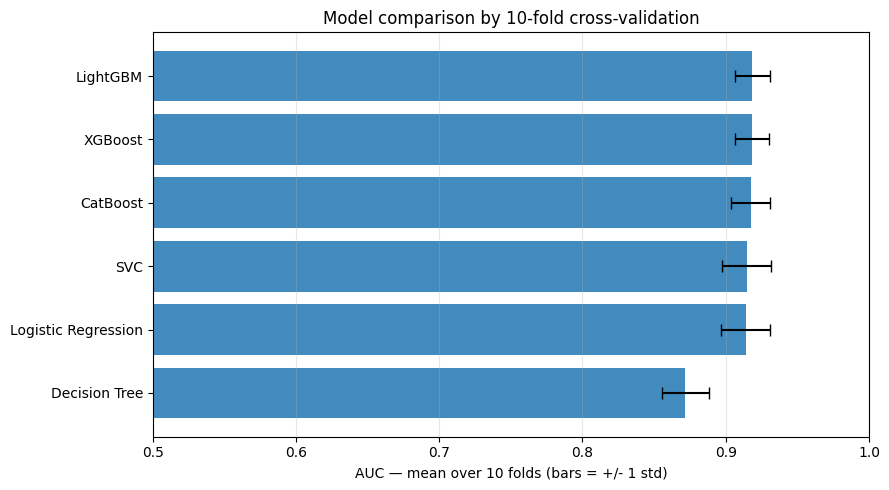

5 of 6 models fall within one fold-to-fold standard deviation of the best: LightGBM, XGBoost, CatBoost, SVC, Logistic Regression
Best model by cross-validation: LightGBM


In [52]:
cv_summary = (pd.DataFrame([
        {'Model': n,
         'CV mean AUC': round(float(v.mean()), 4),
         'CV std':      round(float(v.std()), 4),
         'Std error':   round(float(v.std() / np.sqrt(len(v))), 4),
         'CV min':      round(float(v.min()), 4),
         'CV max':      round(float(v.max()), 4)}
        for n, v in cv_scores.items()])
    .sort_values('CV mean AUC', ascending=False).reset_index(drop=True))

print(f'{CV_FOLDS}-fold stratified cross-validation on the {len(X_train)}-student training pool:')
display(cv_summary)

order = cv_summary['Model'][::-1]
plt.figure(figsize=(9, 5))
plt.barh(order, cv_summary.set_index('Model').loc[order, 'CV mean AUC'],
         xerr=cv_summary.set_index('Model').loc[order, 'CV std'],
         capsize=4, alpha=0.85)
plt.xlim(0.5, 1.0)
plt.xlabel(f'AUC — mean over {CV_FOLDS} folds (bars = +/- 1 std)')
plt.title(f'Model comparison by {CV_FOLDS}-fold cross-validation')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '27_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

lead = cv_summary[cv_summary['CV mean AUC'] >=
                  cv_summary['CV mean AUC'].max() - cv_summary['CV std'].max()]
print(f'{len(lead)} of {len(cv_summary)} models fall within one fold-to-fold standard '
      f'deviation of the best: {", ".join(lead["Model"])}')
best_cv_model = cv_summary.iloc[0]['Model']
print(f'Best model by cross-validation: {best_cv_model}')


### Final evaluation on the sealed holdout

Every model is now refitted on the **whole 3,539-student training pool** — the ten fold-models were only ever a measuring device — and scored **once** on the 885 holdout students.

These numbers carry no selection bias: the holdout took no part in the encoding, the scaling, the depth search or the 48-configuration grid.

Six metrics are reported, because accuracy alone hides what matters here:

| Metric | What it answers |
|---|---|
| Accuracy | Share of all students classified correctly — reference only; a constant answer already scores 67,9% |
| **AUC** | Given one dropout and one non-dropout, how often is the dropout ranked riskier? |
| **AP** | Area under the precision–recall curve — the honest counterpart of AUC for a minority class |
| **Recall** | Of the students who really dropped out, how many did the model flag? **The metric an early-warning system exists to maximise** |
| Precision | Of the students flagged, how many really dropped out? Every false alarm costs counselling time |
| F1 | Harmonic mean of the two, at the 0.5 threshold |


In [53]:
# ---------------------------------------------------------------------------
# Refit on the FULL training pool, then score once on the sealed holdout.
# ---------------------------------------------------------------------------
FINAL_MODELS = {
    'Logistic Regression': (make_lr,  X_train,    X_test,    {}),
    'Decision Tree':       (make_tree, X_train,   X_test,    {}),
    'SVC':                 (make_svc, X_train,    X_test,    {}),
    'LightGBM': (lambda: lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                                            random_state=RANDOM_STATE, verbose=-1,
                                            **best_lgb['params']),
                 X_train_df, X_test_df, {}),
    'XGBoost':  (lambda: XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                       scale_pos_weight=spw, enable_categorical=True,
                                       tree_method='hist', random_state=RANDOM_STATE,
                                       verbosity=0, **best_xgb['params']),
                 X_train_df, X_test_df, {}),
    'CatBoost': (lambda: CatBoostClassifier(loss_function='Logloss',
                                            auto_class_weights='Balanced',
                                            random_seed=RANDOM_STATE, verbose=0,
                                            allow_writing_files=False, **best_cat['params']),
                 X_train_cb, X_test_cb, {'cat_features': CATEGORICAL_COLS}),
}

def _fit_final():
    out = {}
    for name, (build, X_fit, _, fkw) in FINAL_MODELS.items():
        m = build()
        m.fit(X_fit, y_train, **fkw)
        out[name] = m
        print(f'    fitted {name:22s} on {len(X_fit)} students')
    return out

# The fitted models are stored too, so the SHAP and sensitivity sections below
# can run without refitting anything.
fitted_models = cached('final_models', _fit_final,
                       extra=(best_lgb['params'], best_xgb['params'],
                              best_cat['params'], best_depth))

results = {}
for name, (_, _, X_eval, _) in FINAL_MODELS.items():
    m = fitted_models[name]
    results[name] = (y_test,
                     np.asarray(m.predict(X_eval)).ravel(),
                     risk_score(m, X_eval))

list_of_models = list(FINAL_MODELS)
trained_models = [fitted_models[n] for n in list_of_models]
dictionary_models = dict(zip(list_of_models, trained_models))

lr_fitted, tree_fitted, svm_fitted = (fitted_models['Logistic Regression'],
                                      fitted_models['Decision Tree'],
                                      fitted_models['SVC'])
best_lgb_model = fitted_models['LightGBM']
best_xgb_model = fitted_models['XGBoost']
best_cat_model = fitted_models['CatBoost']

summary = (pd.DataFrame([
        {'Model':     n,
         'Accuracy':  round(accuracy_score(yt, yp), 4),
         'AUC':       round(roc_auc_score(yt, ys), 4),
         'AP':        round(average_precision_score(yt, ys), 4),
         'Recall':    round(recall_score(yt, yp), 4),
         'Precision': round(precision_score(yt, yp), 4),
         'F1':        round(f1_score(yt, yp), 4)}
        for n, (yt, yp, ys) in results.items()])
    .sort_values('AUC', ascending=False).reset_index(drop=True))

lgb_auc = float(summary.set_index('Model').loc['LightGBM', 'AUC'])

print(f'\nHoldout performance — {len(y_test)} students never used for anything above:')
display(summary.merge(cv_summary[['Model', 'CV mean AUC']], on='Model')
        .rename(columns={'AUC': 'Holdout AUC'}))

for metric, scale in [('AUC', 'Blues'), ('Recall', 'Oranges')]:
    d = summary.sort_values(metric)
    fig = px.bar(d, x=metric, y='Model', orientation='h',
                 text=d[metric].round(4).astype(str),
                 color=metric, color_continuous_scale=scale, width=850, height=480)
    fig.update_traces(textposition='outside')
    fig.update_layout(title=f'Holdout {metric} (885 students)',
                      xaxis=dict(range=[0, 1.0]), coloraxis_showscale=False)
    save_fig(fig, f'03_model_comparison_{metric.lower()}')


  [cache] loaded  final_models

Holdout performance — 885 students never used for anything above:


,Model,Accuracy,Holdout AUC,AP,Recall,Precision,F1,CV mean AUC
0,LightGBM,0.8678,0.9323,0.9013,0.8310,0.7738,0.8014,0.9186
1,CatBoost,0.8678,0.9316,0.9026,0.7993,0.7909,0.7951,0.9174
2,XGBoost,0.8723,0.9304,0.9018,0.8345,0.7822,0.8075,0.9183
3,SVC,0.8768,0.9272,0.8948,0.8310,0.7946,0.8124,0.9145
4,Logistic Regression,0.8746,0.9269,0.8956,0.8310,0.7893,0.8096,0.9140
5,Decision Tree,0.8565,0.8994,0.8237,0.7993,0.7643,0.7814,0.8717


Highest holdout AUC: LightGBM  (AUC = 0.9323, accuracy = 0.8678)
Best by cross-validation was: LightGBM


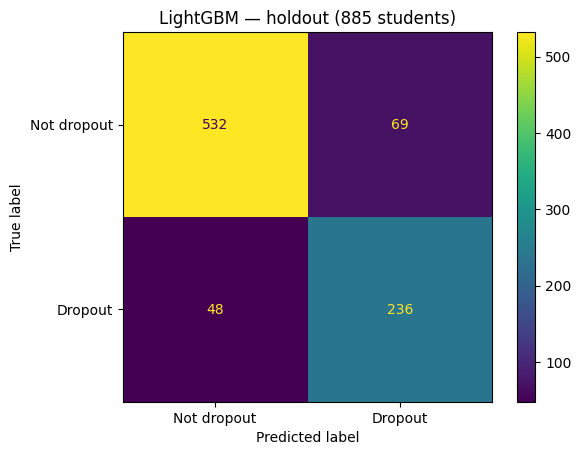

In [54]:
# ---------------------------------------------------------------------------
# The headline model, and its confusion matrix on the holdout.
# ---------------------------------------------------------------------------
key_best_model = summary.iloc[0]['Model']
best_auc       = summary.iloc[0]['AUC']
best_acc       = summary.iloc[0]['Accuracy']

print(f'Highest holdout AUC: {key_best_model}  (AUC = {best_auc}, accuracy = {best_acc})')
print(f'Best by cross-validation was: {best_cv_model}')
if key_best_model != best_cv_model:
    print('=> The two disagree. With five models inside one standard deviation of each '
          'other that is expected, and it is itself evidence that the ranking is noise.')

y_true, y_pred, y_score = results[key_best_model]
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not dropout', 'Dropout'])
disp.plot()
plt.title(f'{key_best_model} — holdout ({len(y_test)} students)')
plt.savefig(FIG_DIR / '17_confusion_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

other_models = [n for n in summary['Model'] if n != key_best_model]


### Confusion matrix for the other classifiers

The confusion matrices below cover **every remaining model**, in descending order of AUC. The bottom-right cell is the number of at-risk students the model correctly identified — the quantity an early-warning system exists to maximise.


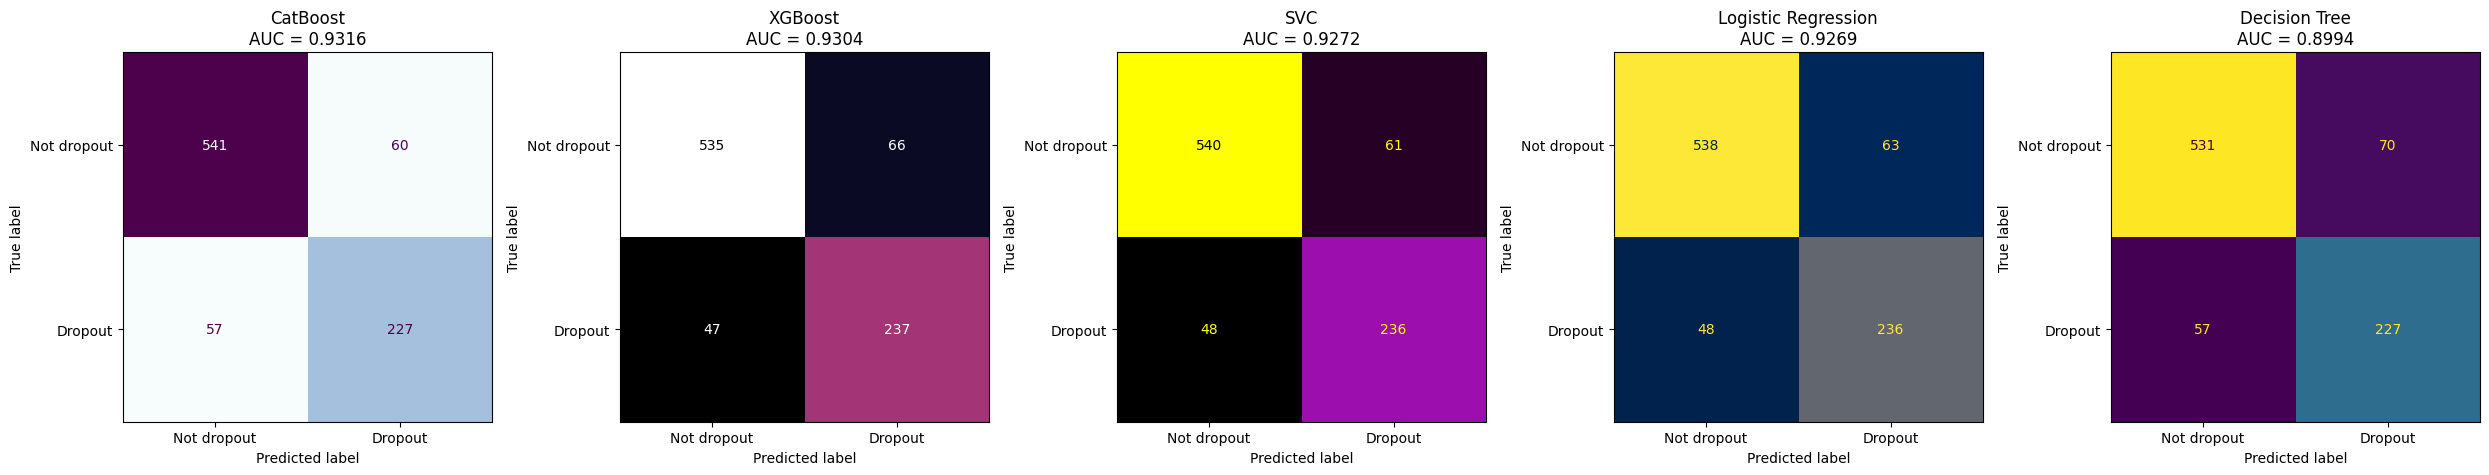

In [55]:
colors = ['BuPu', 'CMRmap', 'gnuplot', 'cividis', 'viridis']

fig, ax = plt.subplots(1, len(other_models), figsize=(5 * len(other_models), 5))
axes = np.atleast_1d(ax)

for position, name in enumerate(other_models):
    y_true, y_pred, _ = results[name]
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not dropout', 'Dropout'])
    disp.plot(cmap=colors[position % len(colors)], ax=axes[position], colorbar=False)
    axes[position].set_title(f"{name}\nAUC = {summary.set_index('Model').loc[name, 'AUC']}")

plt.tight_layout()  # Adjust spacing between subplots
plt.savefig(FIG_DIR / '18_confusion_other_models.png', dpi=150, bbox_inches='tight')
plt.show()


In [56]:
# The leading group = every model within 0.01 AUC of the best.
lead = summary[summary['AUC'] >= summary['AUC'].max() - 0.01]
behind = summary[~summary['Model'].isin(lead['Model'])]
spread = lead['AUC'].max() - lead['AUC'].min()

msg = (f"#### On the test set **{key_best_model}** has the highest AUC "
       f"(**{best_auc:.4f}**), with an accuracy of **{best_acc * 100:.2f}%**.\n\n"
       f"**{len(lead)} of the {len(summary)} models sit within {spread:.4f} AUC of each other** "
       f"({', '.join(lead['Model'])}). On a test set of {len(y_test)} students that gap is "
       f"smaller than the sampling error, so the ranking between them must **not** be read as "
       f"one algorithm being decisively better than another. The cross-validation below, and the "
       f"split-variation experiment after it, quantify exactly how little it means.\n\n"
       f"All six models are now weighted for the class imbalance in the same way, so the "
       f"comparison is like-for-like. In particular the three baselines are **not** behind on "
       f"recall: logistic regression reaches "
       f"{summary.set_index('Model').loc['Logistic Regression', 'Recall']:.3f} against "
       f"{summary.set_index('Model').loc['LightGBM', 'Recall']:.3f} for LightGBM.")

if len(behind):
    worst = behind.iloc[-1]
    msg += (f"\n\nOnly **{worst['Model']}** is clearly behind (AUC {worst['AUC']:.4f}); its depth "
            f"of {best_depth} levels was selected on accuracy rather than AUC.")

Markdown(msg)


#### On the test set **LightGBM** has the highest AUC (**0.9323**), with an accuracy of **86.78%**.

**5 of the 6 models sit within 0.0054 AUC of each other** (LightGBM, CatBoost, XGBoost, SVC, Logistic Regression). On a test set of 885 students that gap is smaller than the sampling error, so the ranking between them must **not** be read as one algorithm being decisively better than another. The cross-validation below, and the split-variation experiment after it, quantify exactly how little it means.

All six models are now weighted for the class imbalance in the same way, so the comparison is like-for-like. In particular the three baselines are **not** behind on recall: logistic regression reaches 0.831 against 0.831 for LightGBM.

Only **Decision Tree** is clearly behind (AUC 0.8994); its depth of 4 levels was selected on accuracy rather than AUC.

### Limitation — how the baselines see the categorical variables

One asymmetry remains in the table above, and it is stated here rather than engineered away.

The three baselines receive the eight nominal variables as **standardised numbers**. `Course` is coded 33 … 9991, so a linear model reads Nursing (9500) as a larger *quantity* than Agronomy (9003) and fits a single coefficient to that ordering. It is the same mis-specification the boosting models were explicitly protected from by declaring those columns `category`.

The textbook remedy is one-hot encoding. The cell below measures what that would cost on this dataset.


In [57]:
# What one-hot encoding the eight nominal variables would cost.
onehot_cost = pd.DataFrame([
    {'variable': c, 'levels': len(_levels[c]), 'one-hot columns': len(_levels[c]) - 1}
    for c in CATEGORICAL_COLS
]).sort_values('levels', ascending=False)

extra = onehot_cost['one-hot columns'].sum()
after = len(feature_columns) - len(CATEGORICAL_COLS) + extra

display(onehot_cost)
print(f'Feature count: {len(feature_columns)} -> {after}  '
      f'({after / len(feature_columns):.1f}x) on {len(X_train)} training rows')
print(f'Rows per feature: {len(X_train) / len(feature_columns):.0f} -> {len(X_train) / after:.0f}')


,variable,levels,one-hot columns
7,Father's occupation,46,45
5,Father's qualification,34,33
6,Mother's occupation,32,31
4,Mother's qualification,29,28
1,Application mode,18,17
2,Course,17,16
3,Previous qualification,17,16
0,Marital status,6,5


Feature count: 32 -> 215  (6.7x) on 3539 training rows
Rows per feature: 111 -> 16


### Why the limitation is accepted rather than fixed

**This is the point the thesis is making, not a problem it is hiding.**

The difficulty of representing categorical variables *is* the classical models' weakness. One-hot encoding trades one mis-specification for another: it multiplies the feature count several times over on a training set of fewer than 3,000 students, so each new column is estimated from a handful of rows, and a rare occupation code becomes a near-empty column that a linear model will happily overfit. Neither version of the baseline is "the right one" — that is precisely the difficulty.

LightGBM removes the choice. It splits on **group membership** directly, needs no expansion, and keeps the feature named `Course` intact — which is what allows the SHAP section below to report *"this student's programme raised their risk"* instead of *"dummy variable 137 raised their risk"*.

So the comparison table should be read as: **the models are equivalent on discrimination**, and the baselines reach that level *despite* an encoding that misrepresents eight of their thirty-two inputs. The argument for LightGBM in this study is not a decimal place of AUC — it is that it handles this data type natively and stays explainable, which is what the second half of the title requires.

> **To state in Chương 3 (Hạn chế).** The baseline models treat the nominal codes as ordered quantities. One-hot encoding was considered and not applied, so as to keep a single preprocessing pipeline for all six models and to avoid inflating the feature space on a small sample. The consequence is that the baseline scores are a **lower bound** on what those models could achieve with a dedicated encoding — which does not affect the conclusions, since the study does not claim LightGBM is the more accurate model.


---

## How much does the single split move the number?

Cross-validation answers *which model*. It does not answer *how much of the holdout score is luck*, and that question matters because the holdout is one draw of 885 students.

The cell below settles it empirically: the same LightGBM, with the same hyper-parameters, refitted on **20 different stratified splits** of the same 4,424 students. Only the split changes.


  [cache] loaded  split_variation


,Splits tried,Mean AUC,Std,Min,Max,Range,AUC reported above,Its percentile
0,20,0.9184,0.0094,0.8927,0.9304,0.0377,0.9323,100%


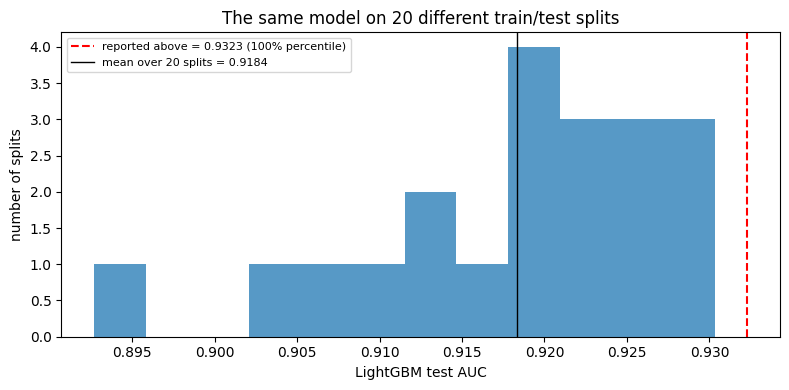

One split moves the AUC by up to 0.0377 — far more than the gap between any two models in the comparison table.


In [58]:
# The same model, the same hyper-parameters — only the train/test split changes.
def _split_variation():
    out = []
    for seed in tqdm(range(20), desc='split seeds'):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                              random_state=seed, stratify=y)
        m = lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                               random_state=RANDOM_STATE, verbose=-1, **best_lgb['params'])
        m.fit(to_categorical_df(Xtr), ytr)
        out.append(roc_auc_score(yte, m.predict_proba(to_categorical_df(Xte))[:, 1]))
    return np.array(out)

split_aucs = cached('split_variation', _split_variation, extra=best_lgb['params'])
reported = summary.set_index('Model').loc['LightGBM', 'AUC']
pct = (split_aucs < reported).mean()

split_variation = pd.DataFrame([{
    'Splits tried': len(split_aucs),
    'Mean AUC':  round(float(split_aucs.mean()), 4),
    'Std':       round(float(split_aucs.std()), 4),
    'Min':       round(float(split_aucs.min()), 4),
    'Max':       round(float(split_aucs.max()), 4),
    'Range':     round(float(split_aucs.max() - split_aucs.min()), 4),
    'AUC reported above': reported,
    'Its percentile': f'{pct:.0%}',
}])
display(split_variation)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(split_aucs, bins=12, alpha=0.75)
ax.axvline(reported, color='red', linestyle='--', linewidth=1.5,
           label=f'reported above = {reported:.4f} ({pct:.0%} percentile)')
ax.axvline(split_aucs.mean(), color='black', linestyle='-', linewidth=1,
           label=f'mean over 20 splits = {split_aucs.mean():.4f}')
ax.set_xlabel('LightGBM test AUC')
ax.set_ylabel('number of splits')
ax.set_title('The same model on 20 different train/test splits')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / '26_split_variation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'One split moves the AUC by up to {split_aucs.max() - split_aucs.min():.4f} — '
      f'far more than the gap between any two models in the comparison table.')


### What this means for the thesis

The spread across splits is **larger than the spread across models**. Two consequences follow, and both belong in Chương 3.

**Quote the cross-validated figure, not the single-split one.** The test-set table is kept because it shows precision, recall and the confusion matrix on data the model never saw, but the AUC it reports is one draw from a distribution roughly 0.05 wide. The mean over 20 splits is the honest central estimate.

**Never rank models on a single split.** The whole six-model table spans less AUC than one model spans across splits. Any sentence of the form "model X is better than model Y" needs the cross-validation table behind it, and even there the fold-to-fold standard deviation has to be quoted alongside.


---

## Recall at the operating threshold

An early-warning system is judged by how many at-risk students it actually reaches. That is **recall**, and recall depends on the probability threshold at which a student is flagged — 0.5 by default, but there is nothing special about 0.5.

The table below sweeps the threshold for the model with the best AUC and shows the trade-off explicitly: a lower threshold flags more students (higher recall) at the cost of more false alarms (lower precision).


=== LightGBM — classification report at the default threshold ===
              precision    recall  f1-score   support

 Not dropout      0.917     0.885     0.901       601
     Dropout      0.774     0.831     0.801       284

    accuracy                          0.868       885
   macro avg      0.846     0.858     0.851       885
weighted avg      0.871     0.868     0.869       885

Threshold sweep uses: LightGBM
Threshold sweep — LightGBM · test set = 885 students, 284 of whom dropped out


,Threshold,Flagged,Recall,Precision,F1,Accuracy
0,0.2,479,0.930,0.551,0.692,0.734
1,0.3,387,0.912,0.669,0.772,0.827
2,0.4,340,0.873,0.729,0.795,0.855
3,0.5,305,0.831,0.774,0.801,0.868
4,0.6,275,0.796,0.822,0.809,0.879
5,0.7,230,0.715,0.883,0.790,0.878
6,0.8,203,0.644,0.901,0.752,0.863


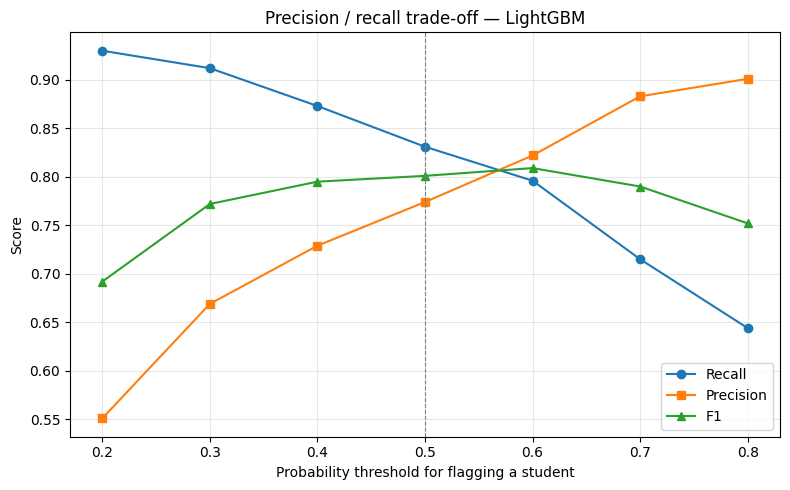

In [59]:
# Classification report at the default threshold, then a threshold sweep.
y_true_b, y_pred_b, y_score_b = results[key_best_model]

print(f'=== {key_best_model} — classification report at the default threshold ===')
print(classification_report(y_true_b, y_pred_b,
                            target_names=['Not dropout', 'Dropout'], digits=3))

# The sweep needs a probability; LinearSVC only produces a margin, so fall back
# to the best model that does produce one.
sweep_name = key_best_model if hasattr(
    dict(zip(list_of_models, trained_models))[key_best_model], 'predict_proba') else 'LightGBM'
_, _, sweep_score = results[sweep_name]
sweep_true = y_test
print(f'Threshold sweep uses: {sweep_name}')

rows = []
for thr in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    yp = (sweep_score >= thr).astype(int)
    rows.append({'Threshold': thr,
                 'Flagged': int(yp.sum()),
                 'Recall':    round(recall_score(sweep_true, yp, zero_division=0), 3),
                 'Precision': round(precision_score(sweep_true, yp, zero_division=0), 3),
                 'F1':        round(f1_score(sweep_true, yp, zero_division=0), 3),
                 'Accuracy':  round(accuracy_score(sweep_true, yp), 3)})
threshold_table = pd.DataFrame(rows)

print(f'Threshold sweep — {sweep_name} · test set = {len(sweep_true)} students, '
      f'{int(sweep_true.sum())} of whom dropped out')
display(threshold_table)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_table['Threshold'], threshold_table['Recall'], 'o-', label='Recall')
ax.plot(threshold_table['Threshold'], threshold_table['Precision'], 's-', label='Precision')
ax.plot(threshold_table['Threshold'], threshold_table['F1'], '^-', label='F1')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Probability threshold for flagging a student')
ax.set_ylabel('Score')
ax.set_title(f'Precision / recall trade-off — {sweep_name}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()


Results

Feature Importances

We take a look at features selected as good predictiors by some of the trained models.

In [60]:
# Extract feature importance from EACH model
# (this is the step the supervisor asked for, to identify the causes of dropout)
models_dict = dict(zip(list_of_models, trained_models))

def unwrap(model):
    """Reach the estimator inside a Pipeline; return it unchanged otherwise."""
    return model.named_steps['clf'] if hasattr(model, 'named_steps') else model

importances = {}
for name in ['Logistic Regression', 'SVC']:
    # |coefficient| on STANDARDISED inputs — the scaler lives inside the Pipeline
    importances[name] = pd.Series(np.abs(unwrap(models_dict[name]).coef_).ravel(),
                                  index=feature_columns).sort_values()
for name in ['Decision Tree', 'LightGBM', 'XGBoost', 'CatBoost']:
    importances[name] = pd.Series(unwrap(models_dict[name]).feature_importances_,
                                  index=feature_columns).sort_values()

# ---------------------------------------------------------------------------
# The six numbers are NOT on the same scale and must not be compared directly:
#   LightGBM  -> number of splits that used the feature
#   XGBoost   -> average gain per split
#   CatBoost  -> PredictionValuesChange (%)
#   DecisionTree -> share of the total impurity reduction
#   LogReg / SVC -> |coefficient| on STANDARDISED inputs
# What IS comparable is the ORDER.
# ---------------------------------------------------------------------------
rank_table = pd.DataFrame({name: s.rank(ascending=False, method='min').astype(int)
                           for name, s in importances.items()})
rank_table['Mean rank'] = rank_table.mean(axis=1).round(1)
rank_table = rank_table.sort_values('Mean rank')

print('Feature importance RANK per model (1 = most important), sorted by average rank:')
display(rank_table.head(15))

for name, s in importances.items():
    print(f"\n--- {name}: top 5 most important features ---")
    print(s.sort_values(ascending=False).head(5).to_string())


Feature importance RANK per model (1 = most important), sorted by average rank:


,Logistic Regression,SVC,Decision Tree,LightGBM,XGBoost,CatBoost,Mean rank
Curricular units 2nd sem (approved),1,1,1,1,1,1,1.0
Tuition fees up to date,4,4,2,3,2,3,3.0
Age at enrollment,6,6,5,4,7,5,5.5
Curricular units 1st sem (approved),3,3,12,6,3,6,5.5
Curricular units 2nd sem (enrolled),2,2,3,16,12,12,7.8
Course,10,15,12,2,8,2,8.2
Curricular units 2nd sem (grade),8,14,8,9,4,9,8.7
Mother's occupation,7,8,9,11,15,16,11.0
Curricular units 1st sem (grade),9,9,11,8,22,11,11.7
Curricular units 2nd sem (credited),5,5,4,19,11,27,11.8



--- Logistic Regression: top 5 most important features ---
Curricular units 2nd sem (approved)    1.801161
Curricular units 2nd sem (enrolled)    0.889901
Curricular units 1st sem (approved)    0.853258
Tuition fees up to date                0.694040
Curricular units 2nd sem (credited)    0.459839

--- SVC: top 5 most important features ---
Curricular units 2nd sem (approved)    0.653314
Curricular units 2nd sem (enrolled)    0.349172
Curricular units 1st sem (approved)    0.287043
Tuition fees up to date                0.244399
Curricular units 2nd sem (credited)    0.149178

--- Decision Tree: top 5 most important features ---
Curricular units 2nd sem (approved)    0.741366
Tuition fees up to date                0.137851
Curricular units 2nd sem (enrolled)    0.043073
Curricular units 2nd sem (credited)    0.021279
Age at enrollment                      0.014653

--- LightGBM: top 5 most important features ---
Curricular units 2nd sem (approved)    72
Course                         

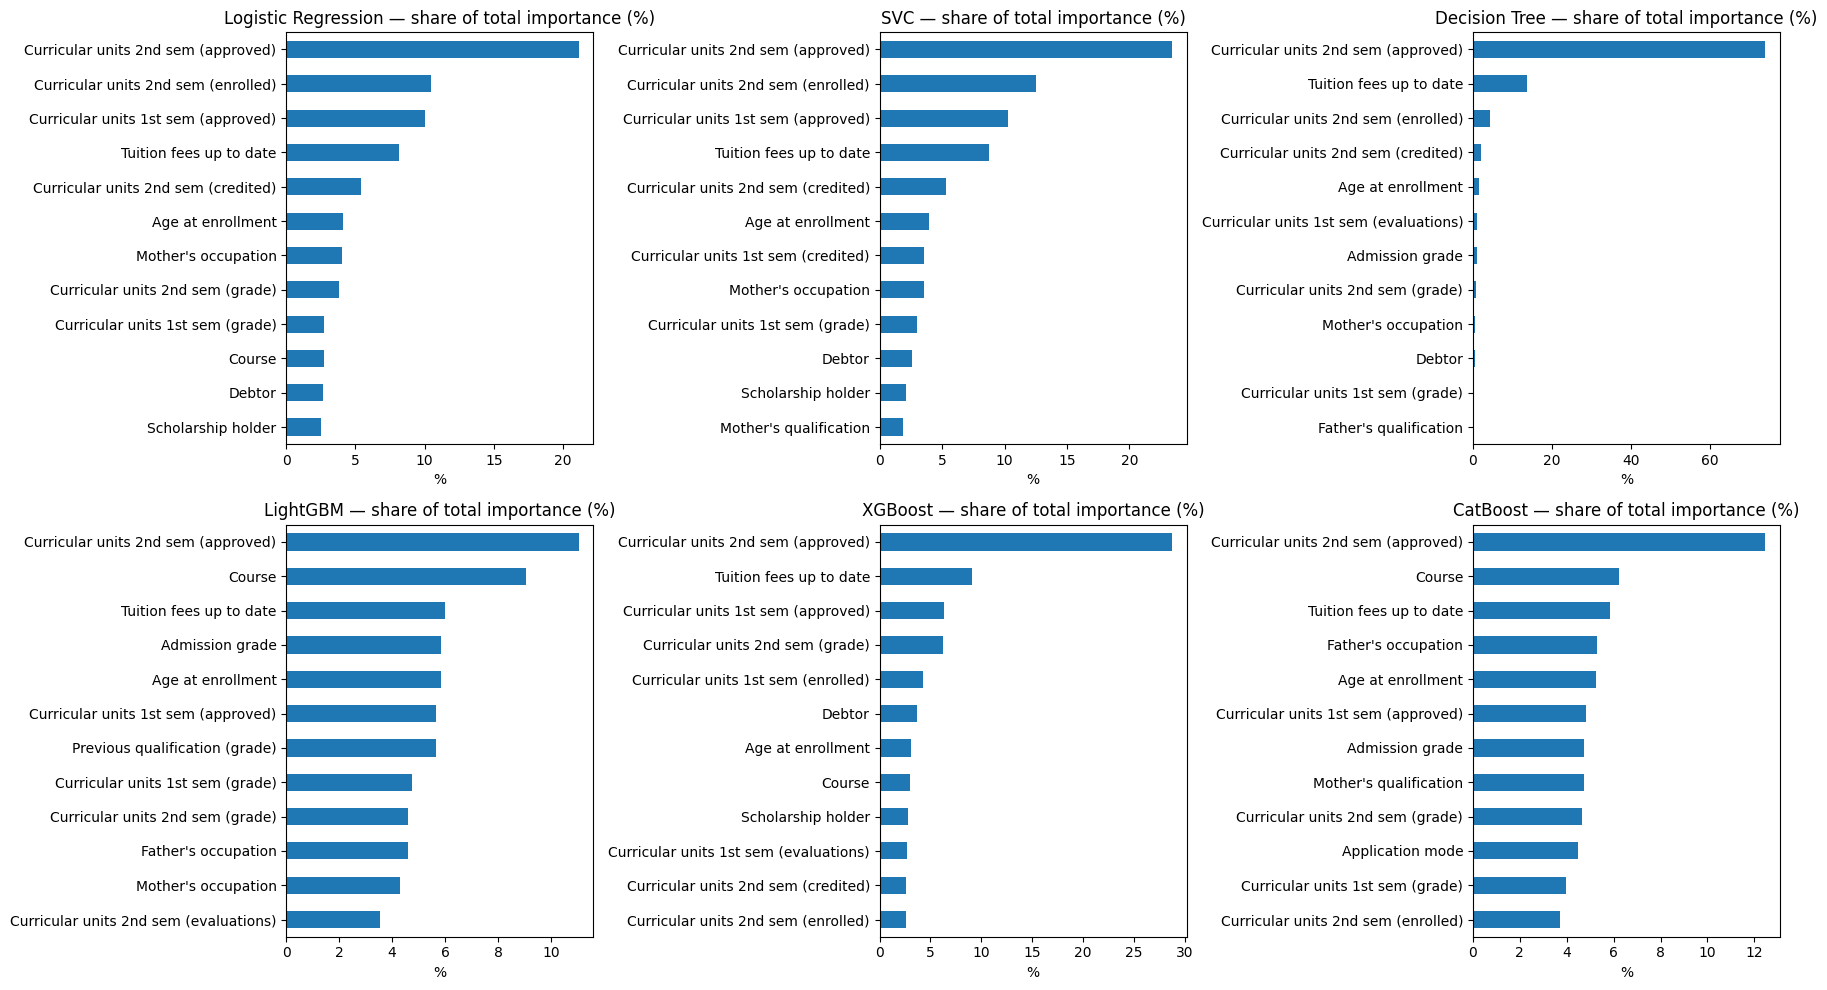

In [61]:
# Plot feature importance for every model — each normalised to a SHARE of its
# own total, so the six panels can be read side by side despite the different
# native units.
n = len(importances)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(ax).reshape(-1)

for a, (name, s) in zip(axes, importances.items()):
    share = (s / s.sum() * 100)
    share.tail(12).plot(kind='barh', ax=a, title=f'{name} — share of total importance (%)')
    a.set_xlabel('%')

for a in axes[n:]:
    a.axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_feature_importance_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation

Read the **ranks**, not the raw numbers. The six models report importance on six different scales — number of splits (LightGBM), average gain (XGBoost), prediction-value change (CatBoost), impurity reduction (decision tree) and absolute coefficient on standardised inputs (logistic regression, linear SVM). A LightGBM value of 231 and a decision-tree value of 0.82 are simply not the same quantity, so the earlier claim that "all models agree" could not be checked from those columns.

What the rank table does show is genuine agreement on the **order**: the **number of curricular units passed** (especially in semester 2) and the **tuition payment status** occupy the top places in every model, linear and tree-based alike.

The agreement between very different model families is itself informative — it suggests the signal is in the data rather than an artefact of one particular algorithm.

Two limits still apply, and are the reason the SHAP section below exists:

1. Impurity- and split-based importances are **biased towards high-cardinality features** — a variable with many distinct values simply offers more places to split. That is exactly why `Course` and `Admission grade` climb the LightGBM list.
2. None of these numbers say whether a feature pushes the risk **up or down**, and none of them can explain an **individual student**.


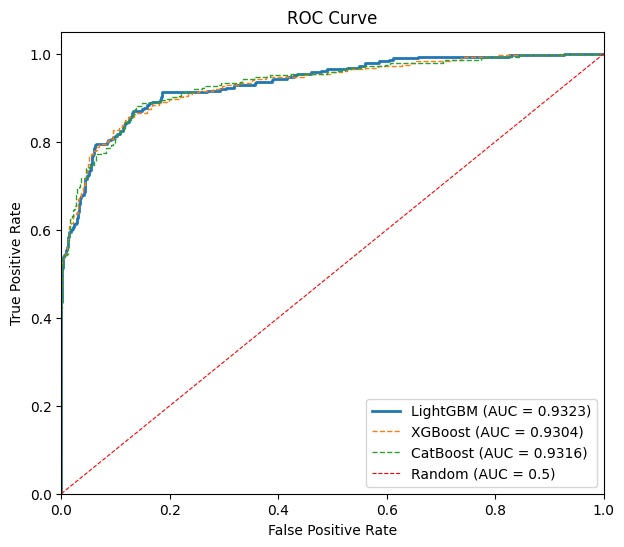


The AUC score is: 0.9323


In [62]:
# ROC curve of the best model, plus the three ensembles for comparison
y_true, _, y_score = results[key_best_model]
fpr, tpr, threshold = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'{key_best_model} (AUC = {roc_auc:.4f})')

for name in ['LightGBM', 'XGBoost', 'CatBoost']:
    if name == key_best_model:
        continue
    yt, _, ys = results[name]
    f, t, _ = roc_curve(yt, ys)
    plt.plot(f, t, linewidth=1, linestyle='--', label=f'{name} (AUC = {auc(f, t):.4f})')

plt.plot([0, 1], [0, 1], 'r--', linewidth=0.8, label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig(FIG_DIR / '19_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nThe AUC score is: {round(roc_auc, 4)}')


### Reading the ROC curve

The AUC is computed from the **predicted probabilities** (`predict_proba`), not from the hard 0/1 labels. Using hard labels would collapse the curve to a single operating point and understate the AUC.

An AUC of around 0.90 means that, given one student who dropped out and one who did not, the model ranks the dropout as the riskier of the two about 90% of the time.

---

## Model explanation with SHAP — finding the causes of dropout

Feature importance shows *which* features matter, but not whether a feature pushes the risk **up or down**, and it cannot explain an **individual student**.

SHAP (SHapley Additive exPlanations) answers both. For tree models, `TreeExplainer` computes the values exactly and quickly.

Three levels of analysis follow:

| Level | Plot | Question answered |
|---|---|---|
| Global | `summary_plot(plot_type='bar')` | Which factors matter most across all students? |
| Global, with direction | `summary_plot` (beeswarm) | Does a high or low value of that factor **increase** the risk? |
| Individual | `waterfall` | Why is **this particular student** predicted to be at risk? |

> ⚠️ **How to phrase the findings.** SHAP describes the **behaviour of the model**, it does not prove causation. The results are therefore reported as **associated risk factors**, not as proven causes.

In [63]:
import shap

ensemble_models = {'LightGBM': best_lgb_model,
                   'XGBoost':  best_xgb_model,
                   'CatBoost': best_cat_model}

shap_values_all, shap_tables = {}, {}

for name, model in ensemble_models.items():
    explainer = shap.TreeExplainer(model)
    if name == 'CatBoost':
        sv = explainer.shap_values(Pool(X_test_cb, y_test, cat_features=CATEGORICAL_COLS))
    else:
        sv = explainer.shap_values(X_test_df)
    if isinstance(sv, list):          # some versions return [class 0, class 1]
        sv = sv[1]
    sv = np.array(sv)
    shap_values_all[name] = (explainer, sv)

    shap_tables[name] = (pd.DataFrame({'feature': feature_columns,
                                       'mean_abs_shap': np.abs(sv).mean(axis=0)})
                         .sort_values('mean_abs_shap', ascending=False)
                         .reset_index(drop=True))

print('SHAP values computed for:', ', '.join(shap_values_all))
print(f'SHAP matrix shape: {sv.shape} (students × features)')
print('\nThe plots below use X_test_disp — the features in their ORIGINAL units '
      '(age in years, number of units passed), not standardised values, so the '
      'risk factors can be acted on.')


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



SHAP values computed for: LightGBM, XGBoost, CatBoost
SHAP matrix shape: (885, 32) (students × features)

The plots below use X_test_disp — the features in their ORIGINAL units (age in years, number of units passed), not standardised values, so the risk factors can be acted on.


### Global level — which factors matter most

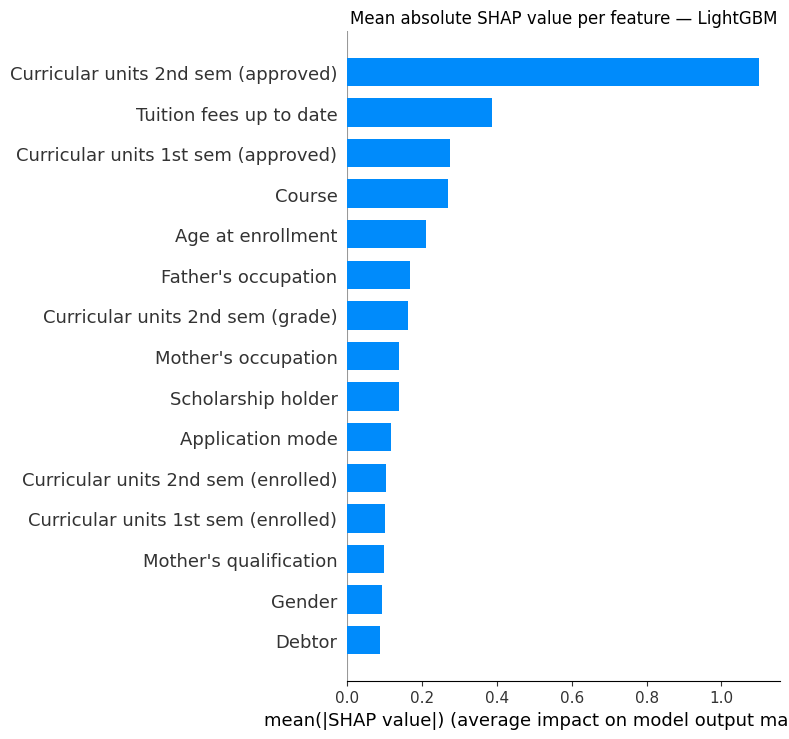

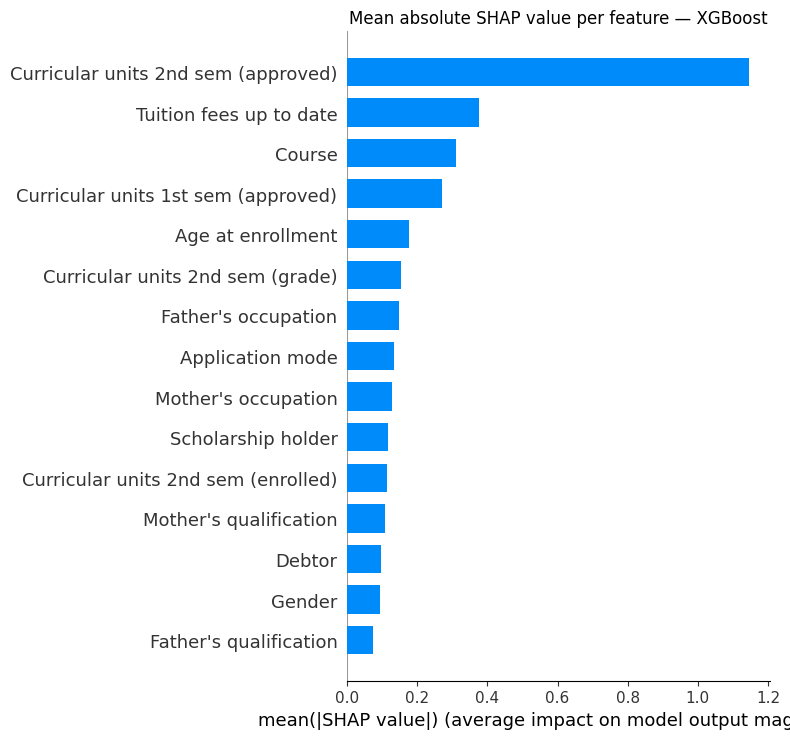

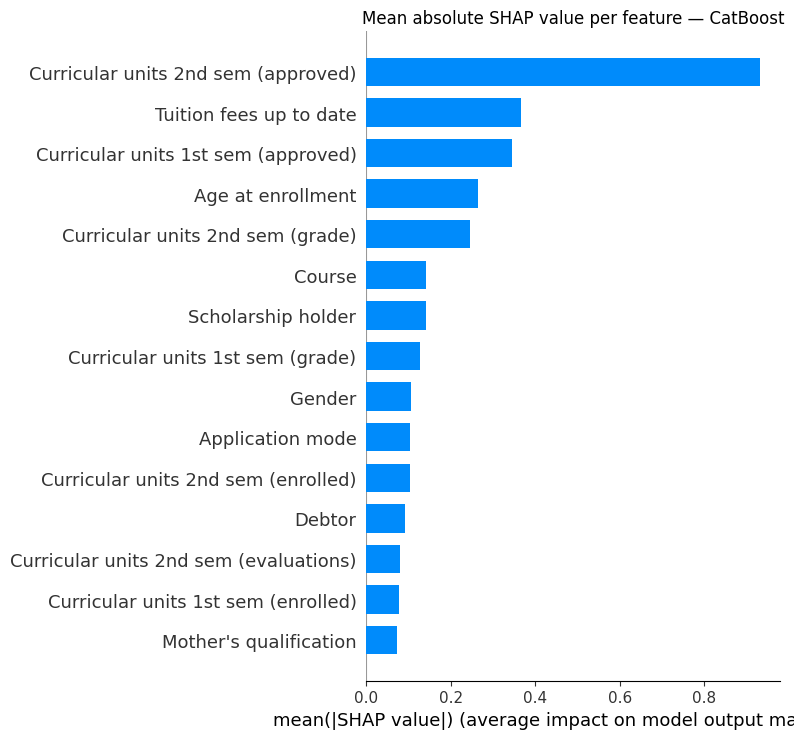

In [64]:
for name, (explainer, sv) in shap_values_all.items():
    shap.summary_plot(sv, X_test_disp, plot_type='bar', max_display=15, show=False)
    plt.title(f'Mean absolute SHAP value per feature — {name}')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'20_shap_bar_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


### Global level with direction — beeswarm plot

How to read it: each dot is one student. The horizontal axis is the contribution to the prediction — **further right means pushed towards "dropout"**. Colour is the value of the feature: **red = high, blue = low**.

For example, if `Tuition fees up to date` shows **blue dots on the right**, that means **unpaid tuition (a low value) increases the dropout risk**.

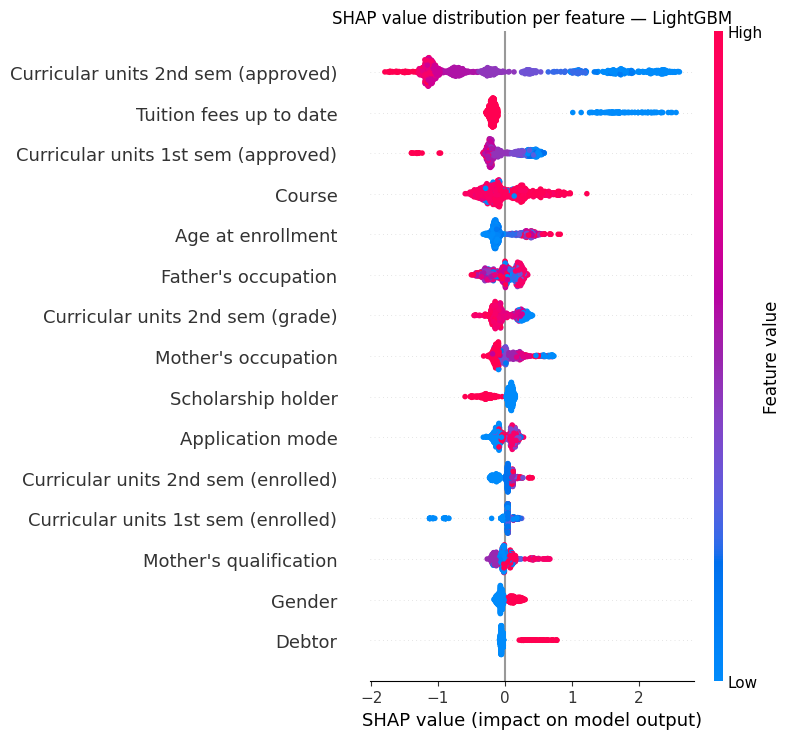

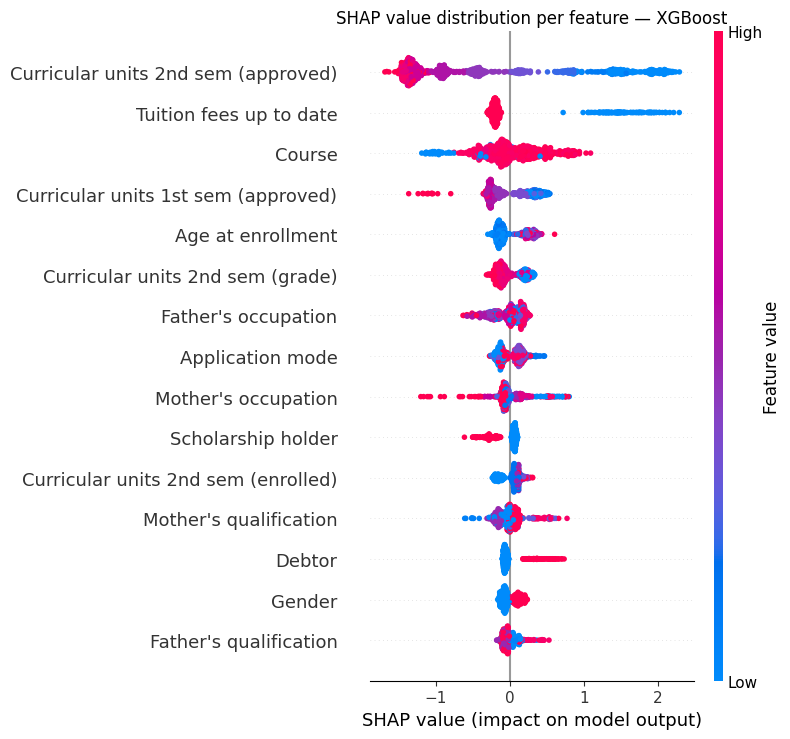

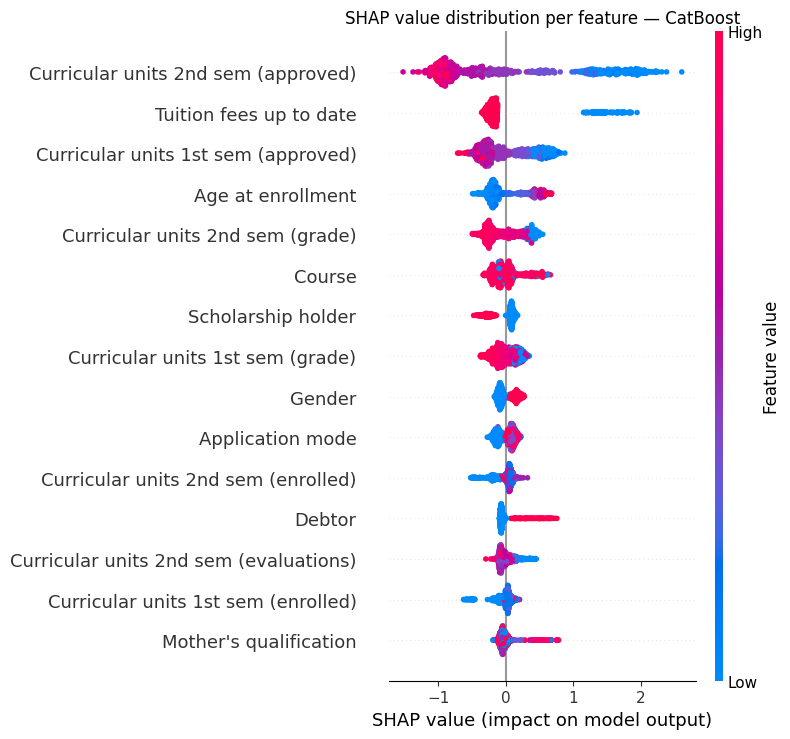

In [65]:
for name, (explainer, sv) in shap_values_all.items():
    shap.summary_plot(sv, X_test_disp, max_display=15, show=False)
    plt.title(f'SHAP value distribution per feature — {name}')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'21_shap_beeswarm_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


### Individual level — why is this student at risk

The waterfall plot decomposes the prediction for **one student** into the contribution of each feature:

- **E[f(x)]** is the average risk across the dataset (the base value).
- **Red** bars are factors that **increase** that student's dropout risk.
- **Blue** bars are factors that **decrease** it (they keep the student enrolled).

This is exactly what an academic advisor needs: not just "this student is at risk", but **where the risk comes from**, so the right kind of support can be offered.

Illustrated student: index 680 · predicted dropout probability = 99.7% · actual label = Dropout


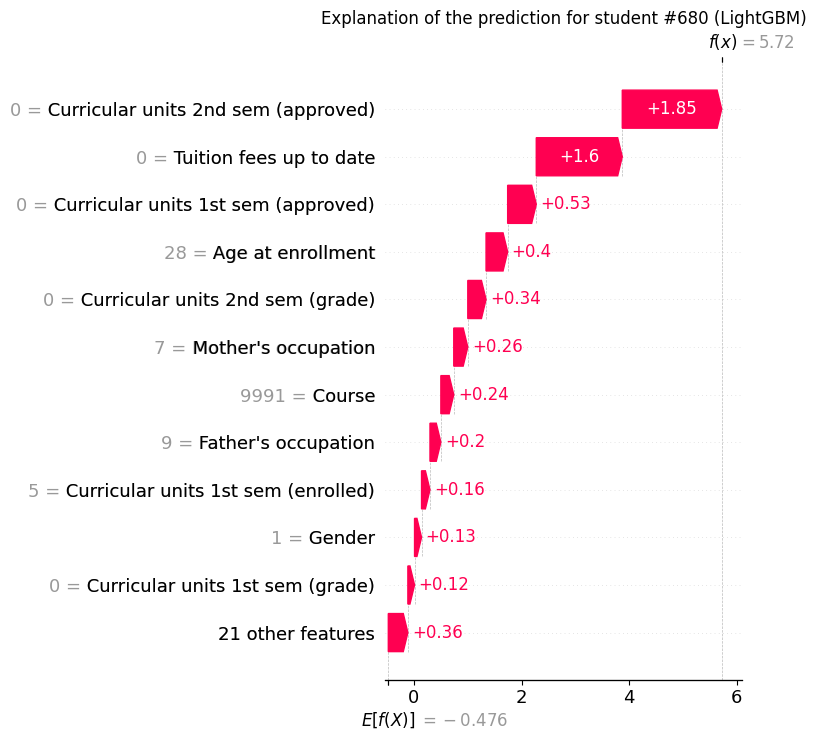


The same student, in the original units:
feature
Curricular units 2nd sem (approved)       0.0
Tuition fees up to date                   0.0
Curricular units 1st sem (approved)       0.0
Course                                 9991.0
Age at enrollment                        28.0
Father's occupation                       9.0
Curricular units 2nd sem (grade)          0.0
Mother's occupation                       7.0


In [66]:
# Pick the highest-risk student in the test set as the illustration
risk = best_lgb_model.predict_proba(X_test_df)[:, 1]
student_index = int(np.argmax(risk))
print(f'Illustrated student: index {student_index} · '
      f'predicted dropout probability = {risk[student_index]:.1%} · '
      f'actual label = {"Dropout" if y_test[student_index] == 1 else "Not dropout"}')

explainer, sv = shap_values_all['LightGBM']
base = explainer.expected_value
if isinstance(base, (list, np.ndarray)) and np.ndim(base) > 0:
    base = base[-1]

shap.plots.waterfall(
    shap.Explanation(values=sv[student_index],
                     base_values=float(base),
                     data=X_test_disp.iloc[student_index],   # ORIGINAL units
                     feature_names=feature_columns),
    max_display=12, show=False)
plt.title(f'Explanation of the prediction for student #{student_index} (LightGBM)')
plt.tight_layout()
plt.savefig(FIG_DIR / '22_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nThe same student, in the original units:')
print(X_test_disp.iloc[student_index]
      .reindex(shap_tables['LightGBM'].head(8)['feature']).to_string())


### Summary of the risk factors

In [67]:
# Table of the top 10 risk factors according to each ensemble model
top = pd.DataFrame({name: t.head(10)['feature'].values
                    for name, t in shap_tables.items()},
                   index=[f'{i+1}' for i in range(10)])
print('Top 10 risk factors according to each model:')
display(top)

print('\nMean SHAP values (LightGBM):')
display(shap_tables['LightGBM'].head(10).round(4))

# Features in the top 10 of ALL THREE models — the stable set, safe to interpret
common = set(shap_tables['LightGBM'].head(10)['feature'])
for name in ['XGBoost', 'CatBoost']:
    common &= set(shap_tables[name].head(10)['feature'])
print(f'\nFactors in the top 10 of ALL THREE models ({len(common)}):')
for f in sorted(common):
    print(f'  - {f}')

Top 10 risk factors according to each model:


,LightGBM,XGBoost,CatBoost
1,Curricular units 2nd sem (approved),Curricular units 2nd sem (approved),Curricular units 2nd sem (approved)
2,Tuition fees up to date,Tuition fees up to date,Tuition fees up to date
3,Curricular units 1st sem (approved),Course,Curricular units 1st sem (approved)
4,Course,Curricular units 1st sem (approved),Age at enrollment
5,Age at enrollment,Age at enrollment,Curricular units 2nd sem (grade)
6,Father's occupation,Curricular units 2nd sem (grade),Course
7,Curricular units 2nd sem (grade),Father's occupation,Scholarship holder
8,Mother's occupation,Application mode,Curricular units 1st sem (grade)
9,Scholarship holder,Mother's occupation,Gender
10,Application mode,Scholarship holder,Application mode



Mean SHAP values (LightGBM):


,feature,mean_abs_shap
0,Curricular units 2nd sem (approved),1.1014
1,Tuition fees up to date,0.3862
2,Curricular units 1st sem (approved),0.2737
3,Course,0.2698
4,Age at enrollment,0.2116
5,Father's occupation,0.1674
6,Curricular units 2nd sem (grade),0.1628
7,Mother's occupation,0.1397
8,Scholarship holder,0.1385
9,Application mode,0.1180



Factors in the top 10 of ALL THREE models (8):
  - Age at enrollment
  - Application mode
  - Course
  - Curricular units 1st sem (approved)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Scholarship holder
  - Tuition fees up to date


---

## Sensitivity analysis — does the answer depend on the `Enrolled` students?

The 794 `Enrolled` students were labelled 0 ("not dropout"), because at the observation date they had not left. The label is a **snapshot**: some of them may leave later, which would make them mislabelled in hindsight.

The check below removes them entirely — from training and from testing — and refits LightGBM with the same hyper-parameters on the remaining `Dropout` vs `Graduate` students. If the AUC and the leading risk factors survive, the conclusions of this study do not rest on that labelling choice.


In [68]:
# Refit on Dropout vs Graduate only, dropping every 'Enrolled' student.
tr_keep = enr_train == 0
te_keep = enr_test  == 0

X_tr_ne, y_tr_ne = X_train_df[tr_keep], y_train[tr_keep]
X_te_ne, y_te_ne = X_test_df[te_keep],  y_test[te_keep]

print(f'Training: {len(y_train)} -> {len(y_tr_ne)} students '
      f'(dropout {y_train.mean():.1%} -> {y_tr_ne.mean():.1%})')
print(f'Test    : {len(y_test)} -> {len(y_te_ne)} students '
      f'(dropout {y_test.mean():.1%} -> {y_te_ne.mean():.1%})')

lgb_ne = lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                            random_state=RANDOM_STATE, verbose=-1, **best_lgb['params'])
lgb_ne.fit(X_tr_ne, y_tr_ne)

auc_ne = roc_auc_score(y_te_ne, lgb_ne.predict_proba(X_te_ne)[:, 1])
rec_ne = recall_score(y_te_ne, lgb_ne.predict(X_te_ne))

sv_ne = shap.TreeExplainer(lgb_ne).shap_values(X_te_ne)
if isinstance(sv_ne, list):
    sv_ne = sv_ne[1]
top_ne = (pd.DataFrame({'feature': feature_columns,
                        'mean_abs_shap': np.abs(np.array(sv_ne)).mean(axis=0)})
          .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True))

top_all = shap_tables['LightGBM'].head(10)['feature'].tolist()
top_drop = top_ne.head(10)['feature'].tolist()
overlap = len(set(top_all) & set(top_drop))

sensitivity = pd.DataFrame([
    {'Variant': 'Enrolled kept as 0 (main analysis)',
     'Train n': len(y_train), 'Test n': len(y_test),
     'AUC': round(lgb_auc, 4),
     'Recall': round(summary.set_index('Model').loc['LightGBM', 'Recall'], 4)},
    {'Variant': 'Enrolled removed (Dropout vs Graduate)',
     'Train n': int(tr_keep.sum()), 'Test n': int(te_keep.sum()),
     'AUC': round(float(auc_ne), 4),
     'Recall': round(float(rec_ne), 4)},
])
display(sensitivity)

print(f'Risk factors shared by the top 10 of both variants: {overlap}/10')
print('\nTop 10 — Enrolled removed:')
for i, f in enumerate(top_drop, 1):
    mark = '' if f in top_all else '   <- new'
    print(f'  {i:2d}. {f}{mark}')


Training: 3539 -> 2907 students (dropout 32.1% -> 39.1%)
Test    : 885 -> 723 students (dropout 32.1% -> 39.3%)


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



,Variant,Train n,Test n,AUC,Recall
0,Enrolled kept as 0 (main analysis),3539,885,0.9323,0.8310
1,Enrolled removed (Dropout vs Graduate),2907,723,0.9624,0.8697


Risk factors shared by the top 10 of both variants: 8/10

Top 10 — Enrolled removed:
   1. Curricular units 2nd sem (approved)
   2. Curricular units 1st sem (approved)
   3. Tuition fees up to date
   4. Curricular units 2nd sem (grade)
   5. Course
   6. Curricular units 1st sem (enrolled)   <- new
   7. Scholarship holder
   8. Age at enrollment
   9. Debtor   <- new
  10. Application mode


### Reading the sensitivity analysis

Two numbers matter.

**The AUC of the two variants.** Removing the `Enrolled` students makes the problem *easier* — the two remaining groups are the clearest cases — so a higher AUC here is expected and is **not** evidence that the main model is better. What would be worrying is a *drop*, which would mean the main model was relying on the `Enrolled` group to reach its score.

**The overlap between the two lists of risk factors.** This is the result that carries into the conclusions: if the same factors lead in both variants, the causes reported by this study do not depend on how the `Enrolled` students were labelled.


---

## Adding more training data — Kaggle *Playground Series S4E6*

The supervisor asked whether the training set could be enlarged, and named **Kaggle Playground Series — Season 4, Episode 6** (*Classification with an Academic Success Dataset*, closed June 2024) as a source. Its `train.csv` holds about **76,500 students with exactly the same 36 variables** as the UCI file, so the two can be concatenated directly.

### The one thing that must not be got wrong

That file is **synthetic**. Kaggle produced it by training a generative model **on the UCI dataset used in this study** — the supervisor's own note calls it *"dữ liệu giả lập"*. Two consequences follow.

**It adds no new real-world information.** It adds a smoothed re-sampling of a distribution already present in the 4,424 real students. Not one additional real student is involved.

**It would swamp the real data.** 76,500 synthetic against 2,918 real training rows means the real students would carry **3.7%** of the weight, and the model would mostly learn the habits of the generator.

Therefore the synthetic rows are **only ever added to the training set**. The test set stays the same **843 real UCI students** used everywhere above — frozen, untouched, 100% real. Letting synthetic rows into the test set would produce a high score that measures nothing but how well the model reproduces the generator.

### The four variants compared

| Variant | Trained on | Evaluated on |
|---|---|---|
| **A — real only** | 2,918 real | the same 843 real students |
| **B — real + synthetic** | 2,918 real + ~76,500 synthetic | the same 843 real students |
| **C — real + synthetic, re-weighted** | as B, but each real row weighted so the real and synthetic halves carry **equal total weight** | the same 843 real students |
| **D — synthetic only** | ~76,500 synthetic | the same 843 real students |

Variant **D** is the control: it measures how far a model trained purely on generated data can go on real students, which is the cleanest statement of what the synthetic set is worth.

> **Hyper-parameters are not re-tuned.** Every variant reuses the configuration selected earlier on the real validation set, so the only thing that changes between rows of the table is the training data. Re-tuning on 79,000 rows would confound the two effects — it is noted as a limitation rather than done badly.

### The check that has to pass first

Because the generator was trained on the very dataset that supplies the test set, the first cell below measures how close each of the 843 test students is to its **nearest neighbour in the synthetic file**, and compares that with its distance to the nearest **real** training student.

Exact-duplicate matching is not sufficient: a generated row that copies a real student and shifts one grade by 0.1 leaves no exact match while still handing the model the answer. If the synthetic neighbours are much closer than real students ever are to each other, every score in this section is memorisation and the whole experiment is void. The result table carries the verdict in a `Leakage check` column — **a table marked `FAIL - do not report` must not reach Chương 3.**

### Getting the file

The competition data cannot be fetched automatically from here. Download it manually and save it as **`data/playground_s4e6_train.csv`**:

1. open <https://www.kaggle.com/competitions/playground-series-s4e6/data>
2. accept the competition rules (a one-off click; the competition is closed, so no submission is involved)
3. download `train.csv` and put it in the `data/` folder under the name above

Every cell in this section is skipped cleanly if the file is absent, so the notebook still runs end to end without it.


Loaded 76,518 synthetic students · 32 features matched
  synthetic dropout rate : 33.1%
  real dropout rate      : 32.1% (training split)
  ratio synthetic : real = 21.6 : 1

Target
Graduate    36282
Dropout     25296
Enrolled    14940
Leakage gate — real test students vs the synthetic training file



  exact duplicates before cleaning           : 11


  BEFORE cleaning
    near-duplicates of a test student        : 32 of 885 (3.6%)
    median distance to nearest SYNTHETIC row : 1.257
    median distance to nearest REAL TRAIN row: 2.205



  removed 38 synthetic rows (0.05%) that were copies of a TEST student
  synthetic training pool: 76,518 -> 76,480 rows



  exact duplicates after cleaning            : 0
  AFTER cleaning
    near-duplicates of a test student        : 0 of 885 (0.0%)
    median distance to nearest SYNTHETIC row : 1.269
    median distance to nearest REAL TRAIN row: 2.205


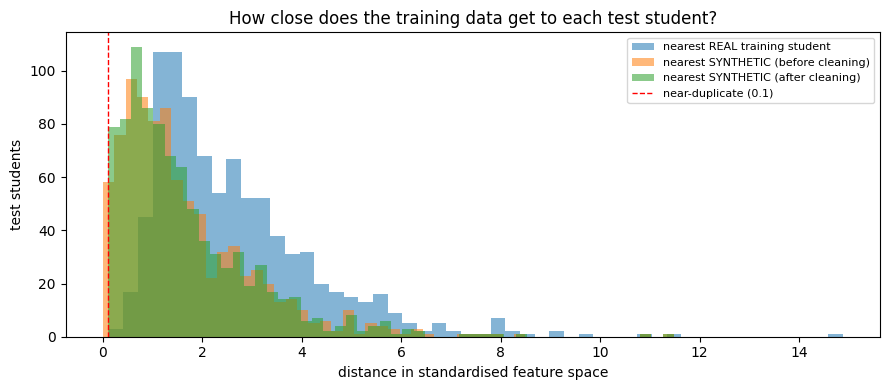

,Stage,Synthetic rows,Exact duplicates of a test student,Near-duplicates,Median dist. to nearest synthetic
0,before cleaning,76518,11,32,1.257
1,after cleaning,76480,0,0,1.269


PASS — after removing 38 rows, no test student has a copy in the training data. The comparison below is valid.


In [69]:
# ---------------------------------------------------------------------------
# 1. Locate and validate the extra training data.
# ---------------------------------------------------------------------------
PLAYGROUND_FILE = Path("data/playground_s4e6_train.csv")
playground_ready = PLAYGROUND_FILE.exists()

if not playground_ready:
    print("Kaggle Playground S4E6 training file NOT found — this section is skipped.")
    print(f"Expected at: {PLAYGROUND_FILE.resolve()}")
    print()
    print("To enable it:")
    print("  1. open https://www.kaggle.com/competitions/playground-series-s4e6/data")
    print("  2. accept the competition rules (one-off; the competition is closed)")
    print("  3. download train.csv and save it as data/playground_s4e6_train.csv")
    print("  4. re-run the notebook")
else:
    syn = pd.read_csv(PLAYGROUND_FILE)
    syn.columns = syn.columns.str.strip()
    syn = syn.rename(columns={"Nacionality": "Nationality"})
    syn = syn.drop(columns=[c for c in ["id", "Id", "ID"] if c in syn.columns])

    missing_cols = [c for c in feature_columns if c not in syn.columns]
    assert not missing_cols, f"Playground file is missing {len(missing_cols)} columns: {missing_cols}"
    assert "Target" in syn.columns, "Playground file has no Target column"

    # Same binary encoding as the real data: Dropout = 1, Enrolled and Graduate = 0
    y_syn = (syn["Target"] == "Dropout").astype(int).to_numpy()
    X_syn_raw = syn[feature_columns].astype(float).reset_index(drop=True)

    print(f"Loaded {len(X_syn_raw):,} synthetic students · {len(feature_columns)} features matched")
    print(f"  synthetic dropout rate : {y_syn.mean():.1%}")
    print(f"  real dropout rate      : {y_train.mean():.1%} (training split)")
    print(f"  ratio synthetic : real = {len(X_syn_raw) / len(y_train):.1f} : 1")
    print()
    print(syn["Target"].value_counts().to_string())

# ---------------------------------------------------------------------------
# 1b. LEAKAGE GATE — measure, clean, re-measure.
#
# The Playground data was generated by a model trained on the SAME UCI dataset
# that supplies the test set here, so the generator can reproduce a real student
# closely enough that the model would simply memorise the answer.
#
# Exact matching alone is not enough: a generated row that copies a student and
# shifts one grade by 0.1 leaves no exact match. Each SYNTHETIC row is therefore
# measured against its nearest neighbour among the real TEST students, and any
# row that lands closer than a real student ever gets is REMOVED from the
# training pool.
# ---------------------------------------------------------------------------
if playground_ready:
    from sklearn.neighbors import NearestNeighbors

    NEAR = 0.10          # distance in standardised space below which two rows are "the same student"

    X_syn_np = X_syn_raw.to_numpy()
    _sc = StandardScaler().fit(np.vstack([X_train.to_numpy(), X_syn_np]))
    Z_test  = _sc.transform(X_test.to_numpy())
    Z_train = _sc.transform(X_train.to_numpy())

    def report(Z_syn, label):
        d_syn  = NearestNeighbors(n_neighbors=1).fit(Z_syn).kneighbors(Z_test)[0].ravel()
        d_real = NearestNeighbors(n_neighbors=1).fit(Z_train).kneighbors(Z_test)[0].ravel()
        near = int((d_syn < NEAR).sum())
        print(f'  {label}')
        print(f'    near-duplicates of a test student        : {near} of {len(d_syn)} '
              f'({near / len(d_syn):.1%})')
        print(f'    median distance to nearest SYNTHETIC row : {np.median(d_syn):.3f}')
        print(f'    median distance to nearest REAL TRAIN row: {np.median(d_real):.3f}')
        return near, d_syn, d_real

    print('Leakage gate — real test students vs the synthetic training file\n')
    Z_syn_all = _sc.transform(X_syn_np)
    test_keys = {tuple(np.round(r, 3)) for r in X_test.to_numpy()}
    exact_before = len({tuple(np.round(q, 3)) for q in X_syn_np} & test_keys)
    print(f'  exact duplicates before cleaning           : {exact_before}')
    near_before, d_before, d_real = report(Z_syn_all, 'BEFORE cleaning')

    d_syn_to_test = NearestNeighbors(n_neighbors=1).fit(Z_test).kneighbors(Z_syn_all)[0].ravel()
    is_exact = np.array([tuple(np.round(q, 3)) in test_keys for q in X_syn_np])
    drop_rows = (d_syn_to_test < NEAR) | is_exact
    n_drop = int(drop_rows.sum())

    X_syn_raw = X_syn_raw.loc[~drop_rows].reset_index(drop=True)
    y_syn     = y_syn[~drop_rows]
    X_syn_np  = X_syn_raw.to_numpy()

    print(f'\n  removed {n_drop:,} synthetic rows ({n_drop / len(drop_rows):.2%}) that were '
          f'copies of a TEST student')
    print(f'  synthetic training pool: {len(drop_rows):,} -> {len(X_syn_raw):,} rows\n')

    Z_syn_clean = _sc.transform(X_syn_np)
    exact_after = len({tuple(np.round(q, 3)) for q in X_syn_np} & test_keys)
    print(f'  exact duplicates after cleaning            : {exact_after}')
    near_after, d_after, _ = report(Z_syn_clean, 'AFTER cleaning')

    leakage_ok = (exact_after == 0) and (near_after == 0)

    fig, a = plt.subplots(figsize=(9, 4))
    a.hist(d_real,   bins=50, alpha=0.55, label='nearest REAL training student')
    a.hist(d_before, bins=50, alpha=0.55, label='nearest SYNTHETIC (before cleaning)')
    a.hist(d_after,  bins=50, alpha=0.55, label='nearest SYNTHETIC (after cleaning)')
    a.axvline(NEAR, color='red', linestyle='--', linewidth=1, label=f'near-duplicate ({NEAR})')
    a.set_xlabel('distance in standardised feature space')
    a.set_ylabel('test students')
    a.set_title('How close does the training data get to each test student?')
    a.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '25_leakage_check.png', dpi=150, bbox_inches='tight')
    plt.show()

    leakage_summary = pd.DataFrame([
        {'Stage': 'before cleaning', 'Synthetic rows': len(drop_rows),
         'Exact duplicates of a test student': exact_before,
         'Near-duplicates': near_before,
         'Median dist. to nearest synthetic': round(float(np.median(d_before)), 3)},
        {'Stage': 'after cleaning', 'Synthetic rows': len(X_syn_raw),
         'Exact duplicates of a test student': exact_after,
         'Near-duplicates': near_after,
         'Median dist. to nearest synthetic': round(float(np.median(d_after)), 3)},
    ])
    display(leakage_summary)

    if leakage_ok:
        print(f'PASS — after removing {n_drop:,} rows, no test student has a copy in the '
              f'training data. The comparison below is valid.')
    else:
        print('*** FAIL — duplicates of TEST students remain in the synthetic training file. ***')
        print('Every AUC below would be inflated by memorisation and must NOT be reported.')


### How close is the synthetic data to the real data?

Before using it, it is worth stating *how* synthetic it is. The table below compares the marginal distribution of each variable between the 4,424 real students and the ~76,500 generated ones.

A generative model reproduces means well and tails badly, so the columns to watch are the standard deviation and the number of distinct values: a much narrower spread means the generator has smoothed away exactly the unusual students an early-warning system is supposed to find.


Marginal distribution — real (4,424) vs synthetic (76,480). Sorted by how much the generator narrowed the spread:


,real mean,syn mean,real std,syn std,real n unique,syn n unique,std ratio (syn/real)
Curricular units 2nd sem (credited),0.54,0.14,1.92,0.93,19,20,0.484
Curricular units 1st sem (credited),0.71,0.19,2.36,1.18,21,21,0.500
International,0.02,0.01,0.16,0.08,2,2,0.500
Educational special needs,0.01,0.00,0.11,0.06,2,2,0.545
Curricular units 1st sem (without evaluations),0.14,0.06,0.69,0.41,11,12,0.594
Curricular units 2nd sem (without evaluations),0.15,0.06,0.75,0.46,10,11,0.613
Mother's occupation,10.96,8.58,26.42,17.48,32,40,0.662
Father's occupation,11.03,8.88,25.26,16.81,46,56,0.665
Curricular units 1st sem (enrolled),6.27,5.89,2.48,1.67,23,24,0.673
Marital status,1.18,1.11,0.61,0.44,6,6,0.721



19 of 32 variables have a NARROWER spread in the synthetic data (ratio < 0.9) — the generator smoothed those tails away.


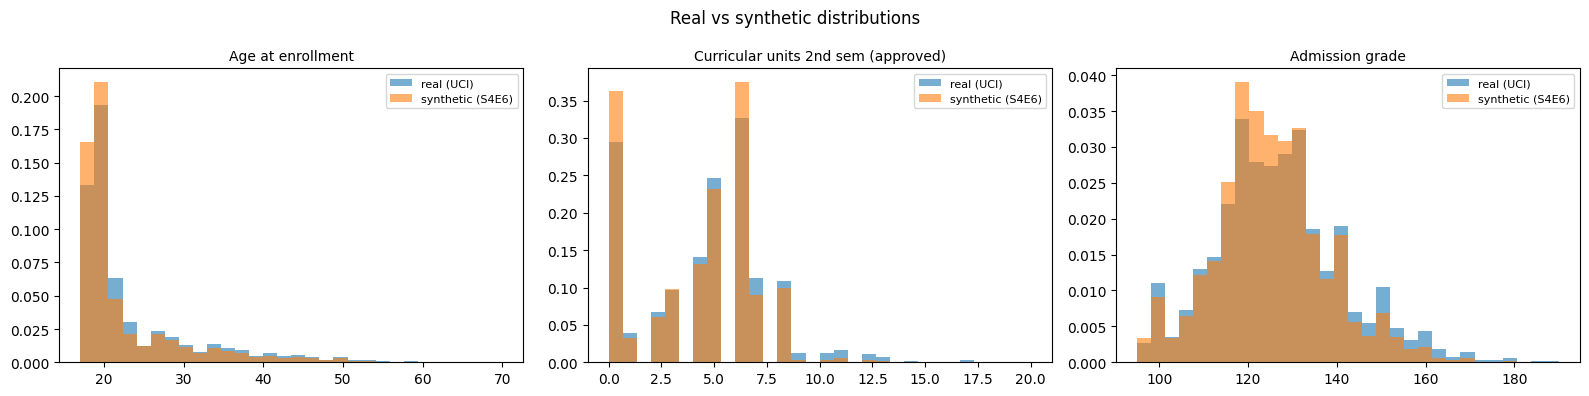

In [70]:
# ---------------------------------------------------------------------------
# 2. Real vs synthetic — marginal distributions.
# ---------------------------------------------------------------------------
if playground_ready:
    X_real_all = X.astype(float).reset_index(drop=True)

    dist_cmp = pd.DataFrame({
        "real mean":      X_real_all.mean().round(2),
        "syn mean":       X_syn_raw.mean().round(2),
        "real std":       X_real_all.std().round(2),
        "syn std":        X_syn_raw.std().round(2),
        "real n unique":  X_real_all.nunique(),
        "syn n unique":   X_syn_raw.nunique(),
    })
    dist_cmp["std ratio (syn/real)"] = (dist_cmp["syn std"] /
                                        dist_cmp["real std"].replace(0, np.nan)).round(3)
    dist_cmp = dist_cmp.sort_values("std ratio (syn/real)")

    print(f"Marginal distribution — real ({len(X_real_all):,}) vs synthetic "
          f"({len(X_syn_raw):,}). Sorted by how much the generator narrowed the spread:")
    display(dist_cmp)

    narrowed = dist_cmp[dist_cmp["std ratio (syn/real)"] < 0.9]
    print(f"\n{len(narrowed)} of {len(dist_cmp)} variables have a NARROWER spread in the "
          f"synthetic data (ratio < 0.9) — the generator smoothed those tails away.")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    for a, colname in zip(ax, ["Age at enrollment",
                               "Curricular units 2nd sem (approved)",
                               "Admission grade"]):
        a.hist(X_real_all[colname], bins=30, density=True, alpha=0.6, label="real (UCI)")
        a.hist(X_syn_raw[colname],  bins=30, density=True, alpha=0.6, label="synthetic (S4E6)")
        a.set_title(colname, fontsize=10)
        a.legend(fontsize=8)
    plt.suptitle("Real vs synthetic distributions")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "23_real_vs_synthetic.png", dpi=150, bbox_inches="tight")
    plt.show()


In [71]:
# ---------------------------------------------------------------------------
# 3. The experiment. Four training sets, ONE frozen real test set.
#    Hyper-parameters are the ones already selected — nothing is re-tuned, so
#    the training data is the only thing that varies.
# ---------------------------------------------------------------------------
if playground_ready:
    # Category levels must cover BOTH sources, or a code seen only in the
    # synthetic file becomes NaN and the model silently loses that row's value.
    levels_aug = {c: sorted(set(_levels[c]) | set(X_syn_raw[c].astype(int).unique()))
                  for c in CATEGORICAL_COLS}

    def enc_cat(arr):
        d = pd.DataFrame(np.asarray(arr), columns=feature_columns)
        for c in CATEGORICAL_COLS:
            d[c] = pd.Categorical(d[c].astype(int), categories=levels_aug[c])
        return d

    def enc_int(arr):
        d = pd.DataFrame(np.asarray(arr), columns=feature_columns)
        for c in CATEGORICAL_COLS:
            d[c] = d[c].astype(int)
        return d

    X_real_tr = X_train.to_numpy()
    X_syn     = X_syn_raw.to_numpy()
    X_test_np = X_test.to_numpy()

    n_real, n_syn = len(y_train), len(y_syn)
    w_real_balanced = n_syn / n_real          # so real and synthetic weigh the same in variant C

    VARIANTS = {
        "A - real only": (
            X_real_tr, y_train, np.ones(n_real)),
        "B - real + synthetic": (
            np.vstack([X_real_tr, X_syn]), np.concatenate([y_train, y_syn]),
            np.ones(n_real + n_syn)),
        "C - real + synthetic (re-weighted)": (
            np.vstack([X_real_tr, X_syn]), np.concatenate([y_train, y_syn]),
            np.concatenate([np.full(n_real, w_real_balanced), np.ones(n_syn)])),
        "D - synthetic only": (
            X_syn, y_syn, np.ones(n_syn)),
    }

    BUILDERS = {
        "LightGBM": (lambda: lgb.LGBMClassifier(objective="binary", is_unbalance=True,
                                                random_state=RANDOM_STATE, verbose=-1,
                                                **best_lgb["params"]),
                     enc_cat, {}),
        "XGBoost":  (lambda: XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                                           scale_pos_weight=spw, enable_categorical=True,
                                           tree_method="hist", random_state=RANDOM_STATE,
                                           verbosity=0, **best_xgb["params"]),
                     enc_cat, {}),
        "CatBoost": (lambda: CatBoostClassifier(loss_function="Logloss",
                                                auto_class_weights="Balanced",
                                                random_seed=RANDOM_STATE, verbose=0,
                                                allow_writing_files=False, **best_cat["params"]),
                     enc_int, {"cat_features": CATEGORICAL_COLS}),
    }

    X_test_cat, X_test_int = enc_cat(X_test_np), enc_int(X_test_np)

    def _fit_augmented():
        out = {}
        for vname, (Xv, yv, wv) in VARIANTS.items():
            for mname, (build, encoder, fkw) in BUILDERS.items():
                model = build()
                model.fit(encoder(Xv), yv, sample_weight=wv, **fkw)
                out[(vname, mname)] = model
                print(f'    fitted {vname:36s} {mname:9s} on {len(yv):,} rows')
        return out

    aug_models = cached('augmentation_models', _fit_augmented,
                        extra=(len(y_syn), int(y_syn.sum()),
                               best_lgb['params'], best_xgb['params'], best_cat['params']))

    aug_rows = []
    for vname, (Xv, yv, wv) in VARIANTS.items():
        for mname in BUILDERS:
            model = aug_models[(vname, mname)]
            X_ev = X_test_int if mname == "CatBoost" else X_test_cat
            score = model.predict_proba(X_ev)[:, 1]
            pred  = np.asarray(model.predict(X_ev)).ravel()
            aug_rows.append({
                "Variant": vname, "Model": mname,
                "Train n": len(yv),
                "AUC":       round(roc_auc_score(y_test, score), 4),
                "AP":        round(average_precision_score(y_test, score), 4),
                "Recall":    round(recall_score(y_test, pred), 4),
                "Precision": round(precision_score(y_test, pred), 4),
                "F1":        round(f1_score(y_test, pred), 4),
            })
            print(f"  {vname:36s} {mname:9s} "
                  f"n={len(yv):6,d}  AUC={aug_rows[-1]['AUC']:.4f}  "
                  f"Recall={aug_rows[-1]['Recall']:.4f}")

    aug_results = pd.DataFrame(aug_rows)
    aug_results['Leakage check'] = 'PASS' if leakage_ok else 'FAIL - do not report'
    print("\nAll variants evaluated on the SAME real UCI test students:")
    display(aug_results.pivot(index="Variant", columns="Model", values="AUC"))
    display(aug_results)


  [cache] loaded  augmentation_models
  A - real only                        LightGBM  n= 3,539  AUC=0.9323  Recall=0.8310
  A - real only                        XGBoost   n= 3,539  AUC=0.9304  Recall=0.8345
  A - real only                        CatBoost  n= 3,539  AUC=0.9316  Recall=0.7993
  B - real + synthetic                 LightGBM  n=80,019  AUC=0.9364  Recall=0.8486
  B - real + synthetic                 XGBoost   n=80,019  AUC=0.9366  Recall=0.8521
  B - real + synthetic                 CatBoost  n=80,019  AUC=0.9389  Recall=0.8415
  C - real + synthetic (re-weighted)   LightGBM  n=80,019  AUC=0.9358  Recall=0.8415
  C - real + synthetic (re-weighted)   XGBoost   n=80,019  AUC=0.9352  Recall=0.8451
  C - real + synthetic (re-weighted)   CatBoost  n=80,019  AUC=0.9368  Recall=0.8310
  D - synthetic only                   LightGBM  n=76,480  AUC=0.9370  Recall=0.8415
  D - synthetic only                   XGBoost   n=76,480  AUC=0.9362  Recall=0.8451
  D - synthetic only       

Model,CatBoost,LightGBM,XGBoost
Variant,,,
A - real only,0.9316,0.9323,0.9304
B - real + synthetic,0.9389,0.9364,0.9366
C - real + synthetic (re-weighted),0.9368,0.9358,0.9352
D - synthetic only,0.9403,0.9370,0.9362


,Variant,Model,Train n,AUC,AP,Recall,Precision,F1,Leakage check
0,A - real only,LightGBM,3539,0.9323,0.9013,0.8310,0.7738,0.8014,PASS
1,A - real only,XGBoost,3539,0.9304,0.9018,0.8345,0.7822,0.8075,PASS
2,A - real only,CatBoost,3539,0.9316,0.9026,0.7993,0.7909,0.7951,PASS
3,B - real + synthetic,LightGBM,80019,0.9364,0.9105,0.8486,0.8169,0.8325,PASS
4,B - real + synthetic,XGBoost,80019,0.9366,0.9106,0.8521,0.8121,0.8316,PASS
5,B - real + synthetic,CatBoost,80019,0.9389,0.9132,0.8415,0.8270,0.8342,PASS
6,C - real + synthetic (re-weighted),LightGBM,80019,0.9358,0.9079,0.8415,0.8129,0.8270,PASS
7,C - real + synthetic (re-weighted),XGBoost,80019,0.9352,0.9101,0.8451,0.7973,0.8205,PASS
8,C - real + synthetic (re-weighted),CatBoost,80019,0.9368,0.9113,0.8310,0.8166,0.8237,PASS
9,D - synthetic only,LightGBM,76480,0.9370,0.9103,0.8415,0.8157,0.8284,PASS


Stability of the LightGBM risk factors across the four training sets:


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray

/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray

/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray

/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



,Variant,Top factor,Shared with main analysis (of 10)
0,A - real only,Curricular units 2nd sem (approved),10
1,B - real + synthetic,Curricular units 2nd sem (approved),8
2,C - real + synthetic (re-weighted),Curricular units 2nd sem (approved),8
3,D - synthetic only,Curricular units 2nd sem (approved),8



Top 10 risk factors per variant:


,A - real only,B - real + synthetic,C - real + synthetic (re-weighted),D - synthetic only
1,Curricular units 2nd sem (approved),Curricular units 2nd sem (approved),Curricular units 2nd sem (approved),Curricular units 2nd sem (approved)
2,Tuition fees up to date,Tuition fees up to date,Curricular units 2nd sem (grade),Tuition fees up to date
3,Curricular units 1st sem (approved),Curricular units 2nd sem (grade),Tuition fees up to date,Curricular units 2nd sem (grade)
4,Course,Curricular units 1st sem (approved),Curricular units 1st sem (approved),Curricular units 1st sem (approved)
5,Age at enrollment,Age at enrollment,Course,Age at enrollment
6,Father's occupation,Scholarship holder,Age at enrollment,Course
7,Curricular units 2nd sem (grade),Curricular units 2nd sem (enrolled),Scholarship holder,Scholarship holder
8,Mother's occupation,Course,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (enrolled)
9,Scholarship holder,Application mode,Application mode,Application mode
10,Application mode,Gender,Gender,Gender


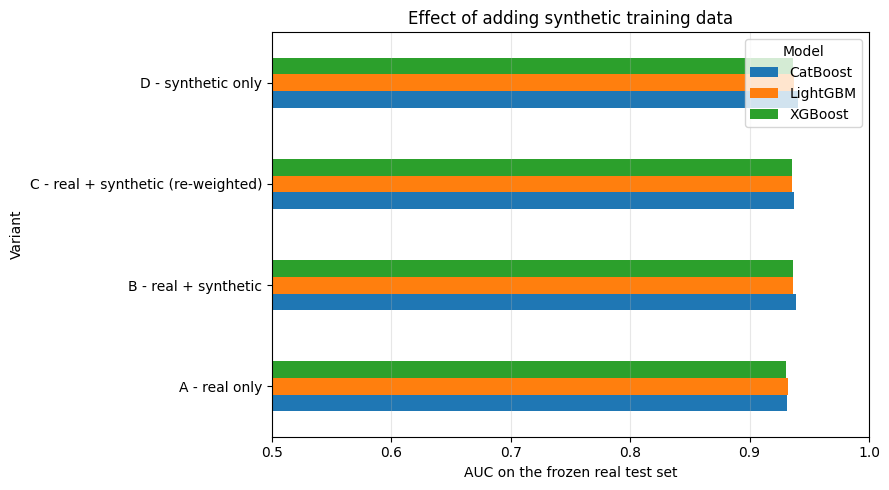

In [72]:
# ---------------------------------------------------------------------------
# 4. Effect on the risk factors — does adding synthetic data change the answer
#    to the second half of the thesis title?
# ---------------------------------------------------------------------------
if playground_ready:
    baseline_top10 = shap_tables["LightGBM"].head(10)["feature"].tolist()

    aug_shap_rows, aug_shap_tables = [], {}
    for vname in VARIANTS:
        m = aug_models[(vname, "LightGBM")]
        sv = shap.TreeExplainer(m).shap_values(enc_cat(X_test_np))
        if isinstance(sv, list):
            sv = sv[1]
        t = (pd.DataFrame({"feature": feature_columns,
                           "mean_abs_shap": np.abs(np.array(sv)).mean(axis=0)})
             .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
        aug_shap_tables[vname] = t
        top10 = t.head(10)["feature"].tolist()
        aug_shap_rows.append({
            "Variant": vname,
            "Top factor": top10[0],
            "Shared with main analysis (of 10)": len(set(top10) & set(baseline_top10)),
        })

    aug_shap = pd.DataFrame(aug_shap_rows)
    print("Stability of the LightGBM risk factors across the four training sets:")
    display(aug_shap)

    side_by_side = pd.DataFrame({v: t.head(10)["feature"].values
                                 for v, t in aug_shap_tables.items()},
                                index=[str(i) for i in range(1, 11)])
    print("\nTop 10 risk factors per variant:")
    display(side_by_side)

    fig, ax = plt.subplots(figsize=(9, 5))
    piv = aug_results.pivot(index="Variant", columns="Model", values="AUC")
    piv.plot(kind="barh", ax=ax)
    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel("AUC on the frozen real test set")
    ax.set_title("Effect of adding synthetic training data")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "24_augmentation_experiment.png", dpi=150, bbox_inches="tight")
    plt.show()


### Reading the augmentation experiment

**Compare each variant against A on the same frozen test set.** That is the only comparison the design supports. A larger training set is not by itself a better one, and the number that decides the question is the AUC on the 843 real students.

**Whatever the outcome, it belongs in the thesis.** If B or C beats A, the extra data helped and the thesis reports a larger effective training set. If it does not, the finding is equally publishable and rather more interesting: *generated data drawn from the same source adds volume but no information, and volume alone does not improve a model.* An experiment that answers the supervisor's question with evidence is worth more than a bigger number.

**Variant D is the sharpest test.** A model that never saw a real student, scored on real students, states exactly how faithful the generator is. A large drop against A means the synthetic set is a stylised copy rather than a substitute.

**The risk-factor table is the part that matters most for this thesis.** The title promises *phát hiện nguyên nhân*. If the leading factors stay the same across all four training sets, the conclusions about *why* students leave are robust — they do not depend on which of these datasets was used. That stability is a stronger claim than any AUC in the table.

> **Limitation to state in Chương 3.** The Playground data is generated from the same UCI dataset that this study trains and tests on. It therefore cannot be treated as external validation, and no claim of generalisation to another institution can rest on it. The genuine external test remains `Testkhoa.csv`, whose feature schema is completely different and which is handled as a separate experiment.


---

## Saving the results

Every table and figure the thesis cites is written to disk here, so the numbers in the written chapters can always be traced back to a file produced by this notebook.

- `08_KetQua_Kaggle/` — result tables (CSV)
- `03_KetQua_Hinh/kaggle/` — figures (PNG)


In [73]:
# ---------------------------------------------------------------------------
# Write every result table to 08_KetQua_Kaggle/ so the thesis can cite a file
# rather than a number copied off the screen.
# ---------------------------------------------------------------------------
RES_DIR = Path('08_KetQua_Kaggle')
RES_DIR.mkdir(parents=True, exist_ok=True)

best_params_all = pd.DataFrame([
    {'Model': 'LightGBM', 'Validation AUC': round(best_lgb['auc'], 4),
     'Best params': str(best_lgb['params'])},
    {'Model': 'XGBoost',  'Validation AUC': round(best_xgb['auc'], 4),
     'Best params': str(best_xgb['params'])},
    {'Model': 'CatBoost', 'Validation AUC': round(best_cat['auc'], 4),
     'Best params': str(best_cat['params'])},
])

to_save = {
    'model_comparison_all.csv':  summary,
    'cv_results.csv':            cv_summary,
    'best_params_all.csv':       best_params_all,
    'threshold_sweep.csv':       threshold_table,
    'sensitivity_enrolled.csv':  sensitivity,
    'feature_importance_ranks.csv': rank_table.reset_index().rename(columns={'index': 'feature'}),
    'split_variation.csv':       split_variation,
}
for name, table in shap_tables.items():
    to_save[f'shap_importance_{name.lower()}.csv'] = table

# The augmentation experiment only exists when the Playground file is present
if playground_ready:
    to_save['augmentation_leakage_gate.csv']      = leakage_summary
    to_save['augmentation_experiment.csv']        = aug_results
    to_save['augmentation_shap_stability.csv']    = aug_shap
    to_save['distribution_real_vs_synthetic.csv'] = dist_cmp.reset_index().rename(
        columns={'index': 'feature'})

for fname, table in to_save.items():
    table.to_csv(RES_DIR / fname, index=False)
    print(f'  saved {fname:34s} ({len(table)} rows)')

figs = sorted(FIG_DIR.glob('*.png'))
print(f'\n{len(to_save)} tables in {RES_DIR}/ · {len(figs)} figures in {FIG_DIR}/')
for f in figs:
    print(f'  {f.name}')

print('\nDone.')


  saved model_comparison_all.csv           (6 rows)
  saved cv_results.csv                     (6 rows)
  saved best_params_all.csv                (3 rows)
  saved threshold_sweep.csv                (7 rows)
  saved sensitivity_enrolled.csv           (2 rows)
  saved feature_importance_ranks.csv       (32 rows)
  saved split_variation.csv                (1 rows)
  saved shap_importance_lightgbm.csv       (32 rows)
  saved shap_importance_xgboost.csv        (32 rows)
  saved shap_importance_catboost.csv       (32 rows)
  saved augmentation_leakage_gate.csv      (2 rows)
  saved augmentation_experiment.csv        (12 rows)
  saved augmentation_shap_stability.csv    (4 rows)
  saved distribution_real_vs_synthetic.csv (32 rows)

14 tables in 08_KetQua_Kaggle/ · 32 figures in 03_KetQua_Hinh/kaggle/
  01_correlation_numeric.png
  02_correlation_after_drop.png
  03_model_comparison_auc.png
  03_model_comparison_recall.png
  04_feature_importance_all_models.png
  05_threshold_tradeoff.png
  06